# 02 Industrial Temporal Pattern — IPAD 산업 설비 시간 패턴 분석

**01 Temporal Vision**을 기반으로, **IPAD(Industrial Process Anomaly Detection)** 데이터셋을 사용해  
산업 설비 영상의 **주기성(Periodicity)** 과 **시간 패턴**을 분석하는 실습입니다.

| 순서 | 주제 |
|------|------|
| 1 | IPAD 데이터셋 준비 및 탐색 |
| 2 | Motion Energy — 설비 동작 강도 시계열 |
| 3 | 주기(Period) 추정 — Autocorrelation / FFT |
| 4 | 주기 단위 사이클 분할 및 시각화 |
| 5 | Optical Flow — 설비 부품 이동 벡터 |
| 6 | 정상 vs 이상 — Z-score 사이클 편차 |
| 7 | STFT 스펙트로그램 — 시간-주파수 패턴 |
| 8 | DTW — 사이클 형태 정렬 & 이상 거리 |
| 9 | CUSUM & Rolling Period — 순차·주기 drift |
| 10 | Mahalanobis — 다변량 사이클 feature 이상 |
| 11 | Operational Phase — 사이클 내 상태 분할 |

### IPAD 실습 데이터 (약 11 MB)

1. 노트북과 **같은 폴더**에 `IPAD_sample.zip` 배치 (실습 배포본)
2. **데이터 탐색 셀 실행 시 자동 압축 해제** → `IPAD_Sample/` 폴더 생성
3. 구조: `IPAD_Sample/{설비명}/training/frames/{클립ID}/*.jpg`

> 샘플: **R01** 설비, train/test 클립 `01` (전체 8GB IPAD 중 실습용 최소 subset)  
> 전체 데이터: [IPAD_dataset.zip](https://drive.google.com/file/d/1SwSScNzhzE6t8N9JxK843SsqthmFdZIv/view) · [논문](https://arxiv.org/abs/2404.15033)


In [1]:
# !pip install -q -r requirements.txt


### 본 실습에서 다루는 기술 한눈에 보기

산업 설비 VAD(Video Anomaly Detection)는 **같은 동작이 주기적으로 반복**된다는 점이 핵심입니다.  
아래 표는 이후 단계에서 코드로 구현하는 기법과, 각각이 무엇을 알려 주는지 정리한 것입니다.

| 기법 | 한 줄 설명 | 코드에서의 역할 |
|------|-----------|----------------|
| **IPAD 프레임 로드** | jpg 시퀀스를 설비·클립 단위로 읽기 | `cv2.imread`, `Path`, `zipfile` |
| **Motion Energy** | 연속 프레임 차분으로 움직임 강도 측정 | `cv2.absdiff`, 시계열 1차 신호 |
| **Autocorrelation / FFT** | 반복 주기(몇 프레임 = 1사이클) 추정 | `scipy.signal.correlate`, `scipy.fft.rfft` |
| **Cycle Segmentation** | 추정 주기로 시계열·영상 분할 | 슬라이싱, overlay 시각화 |
| **Optical Flow (Farneback)** | 픽셀별 이동 방향·속도 | `cv2.calcOpticalFlowFarneback`, HSV |
| **Z-score** | 정상 대비 test 사이클 편차 | `(x-μ)/σ`, bar chart |
| **STFT** | 시간에 따른 주파수 변화 | `scipy.signal.stft` |
| **DTW** | 사이클 곡선 형태 유사도 | 동적 프로그래밍 거리 |
| **CUSUM** | baseline 이탈 시점 탐지 | 누적합 change-point |
| **Mahalanobis** | 다차원 feature 공간 이상 거리 | `np.cov`, PCA 2D |
| **Phase Segmentation** | 사이클 내 운전 단계 분할 | `scipy.signal.find_peaks` |

교통·보행 VAD와 달리, 산업 VAD는 **장비 주기 반복**이 가장 중요한 Temporal 특징입니다.


In [2]:
from __future__ import annotations

import os
import platform
import subprocess
import textwrap
import zipfile
from dataclasses import dataclass
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
from scipy import signal as sp_signal
from scipy.fft import rfft, rfftfreq

# ── 경로 설정 ──────────────────────────────────────────────────────────────

# 실습용 zip (노트북과 같은 폴더) — 실행 시 자동 압축 해제
# Windows는 대소문자 구분 없이 IPAD_sample.zip / IPAD_Sample.zip 모두 인식
IPAD_ZIP_NAMES = ("IPAD_sample.zip", "IPAD_Sample.zip")
# zip 내부 최상위 폴더명과 일치해야 find_ipad_root()가 바로 탐색 가능
IPAD_EXTRACT_DIR = Path("IPAD_Sample")

# 압축 해제 후 데이터 루트 탐색 순서
# 위에서부터 존재·구조가 유효한 첫 경로를 IPAD 루트로 사용
IPAD_SEARCH_PATHS = [
    IPAD_EXTRACT_DIR,
    Path("IPAD_sample"),
    Path("IPAD"),
]

# 분석 결과(그래프·로그) 저장 위치 — 실행할 때마다 덮어씀
OUTPUT_DIR = Path("output_ipad")
FIG_DIR = OUTPUT_DIR / "figures"

# IPAD_sample.zip 구성 (R01 / 클립 01) — 샘플과 동일하게 고정
# None으로 두면 설비·클립 이름 정렬 후 첫 항목 자동 선택
SELECTED_DEVICE: str | None = "R01"
SELECTED_CLIP: str | None = "01"
SELECTED_TEST_CLIP: str | None = "01"

# 출력 폴더가 없으면 미리 생성 (이후 savefig 경로 오류 방지)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)


def is_running_in_colab() -> bool:
    """Google Colab 런타임 여부 — 한글 폰트 설치 분기용."""
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False


def setup_matplotlib_korean() -> None:
    """
    matplotlib 한글·마이너스 기호 깨짐 방지.
    OS별로 설치된 고딕 계열 폰트를 우선 탐색하고, 없으면 ttf 직접 등록.
    """
    from matplotlib import font_manager
    if is_running_in_colab():
        # Colab 기본 이미지에는 나눔 폰트가 없어 apt로 설치
        subprocess.run(
            ["apt-get", "-qq", "-y", "install", "fonts-nanum"],
            check=False, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
        )
        font_manager._load_fontmanager(try_read_cache=False)
    if platform.system() == "Windows":
        candidates = ["Malgun Gothic", "NanumGothic", "Gulim"]
        fallback = Path(os.environ.get("WINDIR", r"C:\Windows")) / "Fonts" / "malgun.ttf"
    elif platform.system() == "Darwin":
        candidates = ["AppleGothic", "Apple SD Gothic Neo"]
        fallback = None
    else:
        candidates = ["NanumGothic", "NanumBarunGothic"]
        fallback = Path("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
    available = {f.name for f in font_manager.fontManager.ttflist}
    chosen = next((n for n in candidates if n in available), None)
    if chosen:
        plt.rcParams["font.family"] = chosen
    elif fallback and fallback.exists():
        font_manager.fontManager.addfont(str(fallback))
        plt.rcParams["font.family"] = font_manager.FontProperties(fname=str(fallback)).get_name()
    # 유니코드 마이너스(−) 대신 ASCII '-' 사용 — 축 숫자 깨짐 방지
    plt.rcParams["axes.unicode_minus"] = False


setup_matplotlib_korean()
print("환경 설정 완료")


환경 설정 완료


In [3]:
# IPAD가 제공하는 프레임 이미지 확장자 — mp4 등 비디오 파일은 사용하지 않음
FRAME_EXTS = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp"}


@dataclass
class IpadClip:
    """IPAD 프레임 시퀀스 클립 (설비 1개 영상 = 프레임 폴더)."""
    device: str          # 설비 코드 (예: R01, S03)
    split: str          # training / testing
    clip_id: str        # 클립 폴더명 (예: 01)
    frame_dir: Path     # .../frames/{clip_id}/ 절대·상대 경로
    frame_paths: list[Path]  # 정렬된 프레임 파일 경로 목록

    @property
    def num_frames(self) -> int:
        """클립에 포함된 프레임 수 — Motion Energy 길이는 num_frames-1."""
        return len(self.frame_paths)


def _is_valid_ipad_root(base: Path) -> bool:
    """하위에 `{설비}/training/frames/` 가 있으면 유효한 IPAD 루트."""
    if not base.is_dir():
        return False
    # 일반 구조: 루트 아래 여러 설비 폴더
    for child in base.iterdir():
        if child.is_dir() and (child / "training" / "frames").is_dir():
            return True
    # base가 설비 폴더 자체인 경우 (training/frames가 바로 아래)
    return (base / "training" / "frames").is_dir()


def find_ipad_zip() -> Path | None:
    """현재 작업 디렉터리에서 IPAD_sample.zip 파일을 찾는다."""
    cwd = Path(".")
    # 고정 파일명 후보를 먼저 확인
    for name in IPAD_ZIP_NAMES:
        p = cwd / name
        if p.is_file():
            return p
    # 파일명 대소문자가 다른 경우를 위한 느슨한 탐색
    for f in cwd.iterdir():
        if f.is_file() and f.suffix.lower() == ".zip" and f.stem.lower() == "ipad_sample":
            return f
    return None


def ensure_ipad_sample() -> Path | None:
    """
    IPAD_sample.zip을 현재 경로에서 찾아, 필요 시 IPAD_Sample/ 로 압축 해제한다.
    이미 풀려 있으면 재추출하지 않는다.
    """
    # 이미 유효한 데이터 폴더가 있으면 zip 없이도 진행
    for base in IPAD_SEARCH_PATHS:
        if _is_valid_ipad_root(base):
            return base

    zip_path = find_ipad_zip()
    if zip_path is None:
        return None

    print(f"[IPAD] {zip_path.name} 압축 해제 중 → {Path('.').resolve()}")
    # zip 내부 경로(IPAD_Sample/R01/...) 구조를 그대로 현재 폴더에 복원
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(".")

    for base in IPAD_SEARCH_PATHS:
        if _is_valid_ipad_root(base):
            print(f"[IPAD] 데이터 준비 완료: {base.resolve()}")
            return base
    return None


def find_ipad_root() -> Path | None:
    """
    IPAD_sample.zip 자동 해제 후 데이터셋 루트를 탐색한다.
    하위에 `{설비}/training/frames/` 구조가 있으면 유효한 루트로 판단.
    """
    ensure_ipad_sample()
    for base in IPAD_SEARCH_PATHS:
        if not base.exists():
            continue
        if _is_valid_ipad_root(base):
            return base
        # base 자체가 설비 폴더인 경우 (training/frames 가 바로 있음)
        if (base / "training" / "frames").is_dir():
            return base.parent
    return None


def list_ipad_devices(root: Path) -> list[str]:
    """주기 분석 가능한 설비(device) 폴더 이름 목록."""
    devices = []
    for child in sorted(root.iterdir()):
        if child.is_dir() and (child / "training" / "frames").is_dir():
            devices.append(child.name)
    return devices


def list_clips(device_dir: Path, split: str = "training") -> list[str]:
    """split(training/testing) 아래 frames/{clip_id}/ 목록."""
    frames_root = device_dir / split / "frames"
    if not frames_root.is_dir():
        return []
    return sorted(d.name for d in frames_root.iterdir() if d.is_dir())


def load_ipad_clip(
    root: Path,
    device: str,
    split: str,
    clip_id: str,
    max_frames: int | None = None,
) -> IpadClip:
    """
    IPAD 프레임 폴더에서 jpg/png 시퀀스 경로를 수집한다.
    OpenCV VideoCapture 대신 프레임 이미지 나열 방식(IPAD 원본 형식).
    """
    frame_dir = root / device / split / "frames" / clip_id
    if not frame_dir.is_dir():
        raise FileNotFoundError(f"클립 없음: {frame_dir}")

    # 파일명 정렬 → 000.jpg, 001.jpg ... 시간 순서 보장
    paths = sorted(
        p for p in frame_dir.iterdir()
        if p.is_file() and p.suffix.lower() in FRAME_EXTS
    )
    if not paths:
        raise ValueError(f"프레임 파일 없음: {frame_dir}")
    if max_frames is not None:
        paths = paths[:max_frames]

    return IpadClip(device, split, clip_id, frame_dir, paths)


def read_frames_bgr(clip: IpadClip) -> list[np.ndarray]:
    """클립의 모든 프레임을 BGR numpy 배열로 읽는다."""
    frames = []
    for p in clip.frame_paths:
        img = cv2.imread(str(p))
        if img is None:
            raise IOError(f"프레임 읽기 실패: {p}")
        frames.append(img)
    return frames


def try_load_anomaly_labels(root: Path, device: str) -> np.ndarray | None:
    """
    IPAD 이상 프레임 라벨(npy)을 로드한다.
    zip 내부 `data/frame_labels_{device}.npy` 또는 유사 경로.
    0=정상, 1=이상 (논문 VAD 설정).
    """
    candidates = list(root.rglob(f"frame_labels_{device}.npy"))
    candidates += list(root.rglob("frame_labels_*.npy"))
    for p in candidates:
        try:
            labels = np.load(p, allow_pickle=True)
            print(f"[라벨] 로드: {p}")
            return labels
        except Exception:
            continue
    return None


def resolve_ipad_session(
    device: str | None = None,
    clip_id: str | None = None,
) -> tuple[Path, IpadClip, IpadClip | None]:
    """
    IPAD 루트·학습(정상) 클립·테스트(이상 포함) 클립을 결정한다.
    데이터가 없으면 FileNotFoundError + 안내 메시지.
    """
    root = find_ipad_root()
    if root is None:
        raise FileNotFoundError(
            "IPAD 데이터셋을 찾을 수 없습니다.\n"
            "  노트북과 같은 폴더에 IPAD_sample.zip 을 두고\n"
            "  데이터 탐색 셀을 다시 실행하세요.\n"
            "  (자동 압축 해제 → IPAD_Sample/ 폴더 생성)"
        )

    devices = list_ipad_devices(root)
    if not devices:
        raise FileNotFoundError(f"설비 폴더 없음: {root}")

    # 인자 > SELECTED_* > 목록 첫 항목 순으로 설비·클립 결정
    dev = device or SELECTED_DEVICE or devices[0]
    if dev not in devices:
        raise ValueError(f"설비 '{dev}' 없음. 사용 가능: {devices}")

    device_dir = root / dev
    train_clips = list_clips(device_dir, "training")
    test_clips = list_clips(device_dir, "testing")

    if not train_clips:
        raise FileNotFoundError(f"training 클립 없음: {device_dir}")

    cid = clip_id or SELECTED_CLIP or train_clips[0]
    train_clip = load_ipad_clip(root, dev, "training", cid)

    test_clip = None
    if test_clips:
        tid = SELECTED_TEST_CLIP or test_clips[0]
        test_clip = load_ipad_clip(root, dev, "testing", tid)

    print(f"[IPAD] root={root.resolve()}")
    print(f"       device={dev}, train_clip={cid} ({train_clip.num_frames} frames)")
    if test_clip:
        print(f"       test_clip={test_clip.clip_id} ({test_clip.num_frames} frames)")
    return root, train_clip, test_clip


## 1. IPAD 데이터셋 탐색

### 이 단계에서 쓰는 기술

**IPAD 데이터 형식**  
IPAD는 mp4가 아니라 **프레임 이미지 폴더**(`000.jpg`, `001.jpg`, …)로 제공됩니다.  
경로 구조는 `{설비}/training/frames/{클립ID}/` (정상)과 `testing/` (이상 포함)입니다.

**자동 압축 해제 (`zipfile`)**  
`IPAD_sample.zip`을 노트북과 같은 폴더에 두면, `ensure_ipad_sample()`이 zip을 찾아 `IPAD_Sample/`로 풀어 줍니다. 이미 풀려 있으면 다시 추출하지 않습니다.

**데이터 탐색 (`pathlib`)**  
`find_ipad_root()` → 설비 목록 → train/test 클립 ID → `IpadClip` dataclass에 프레임 경로를 모읍니다.

**프레임 로드 (`OpenCV`)**  
`read_frames_bgr()`가 각 jpg를 BGR `numpy` 배열로 읽습니다. 이후 모든 분석은 이 프레임 리스트를 입력으로 사용합니다.

**실습 샘플 고정값**  
`SELECTED_DEVICE="R01"`, `SELECTED_CLIP="01"` — 배포용 zip과 동일한 클립을 분석합니다.


In [4]:
# ── IPAD 탐색 및 클립 로드 ──
# resolve_ipad_session: zip 자동 해제 → train/test 클립 메타데이터 확보
ipad_root, train_clip, test_clip = resolve_ipad_session()

# 데이터셋에 포함된 설비·클립 목록 출력 (샘플 zip은 R01/01만 존재)
print("\n[설비 목록]", list_ipad_devices(ipad_root))
print("[training 클립]", list_clips(ipad_root / train_clip.device, "training")[:5], "...")
if test_clip:
    print("[testing 클립]", list_clips(ipad_root / train_clip.device, "testing")[:5], "...")

# BGR 프레임 리스트로 로드 — 이후 Motion Energy·Optical Flow 입력
train_frames = read_frames_bgr(train_clip)
h, w = train_frames[0].shape[:2]
fps_assumed = 30.0  # IPAD 논문: 대부분 30 FPS 렌더/촬영
duration = len(train_frames) / fps_assumed
print(f"\n[클립 정보] 해상도 {w}x{h}, {len(train_frames)} frames, ~{duration:.1f}초 (@{fps_assumed}fps)")


[IPAD] IPAD_sample.zip 압축 해제 중 → C:\MyCursorLab\08_Video AI 처리 및 분석
[IPAD] 데이터 준비 완료: C:\MyCursorLab\08_Video AI 처리 및 분석\IPAD_Sample
[IPAD] root=C:\MyCursorLab\08_Video AI 처리 및 분석\IPAD_Sample
       device=R01, train_clip=01 (207 frames)
       test_clip=01 (230 frames)

[설비 목록] ['R01']
[training 클립] ['01'] ...
[testing 클립] ['01'] ...

[클립 정보] 해상도 256x256, 207 frames, ~6.9초 (@30.0fps)


## 2. Motion Energy — 설비 동작 강도

### 이 단계에서 쓰는 기술

**Motion Energy (프레임 차분)**  
연속 두 프레임의 그레이스케일 차이 `|F(t+1)−F(t)|`를 픽셀 평균하면, **프레임마다 하나의 숫자**가 나옵니다.

- 값이 **크다** → 벨트·로봇팔·리프트 등이 **움직이는 구간**
- 값이 **작다** → **정지·대기** 구간

산업 설비는 이 peak / trough가 **주기적으로 반복**되므로, 이후 주기 추정·사이클 분할의 **1차 입력 신호**가 됩니다.

**Farneback Optical Flow magnitude (보조)**  
`cv2.calcOpticalFlowFarneback`으로 픽셀별 이동 벡터를 구하고, 크기(magnitude)의 공간 평균을 냅니다.  
Motion Energy는 “변화량”, Flow는 “이동량”을 보므로 **서로 보완**합니다.

**시각화 (`matplotlib`)**  
두 시계열을 시간(초) 축으로 겹쳐 그려, 정상 클립의 **동작 리듬**을 눈으로 확인합니다.


저장: output_ipad\figures\01_motion_energy_train.png


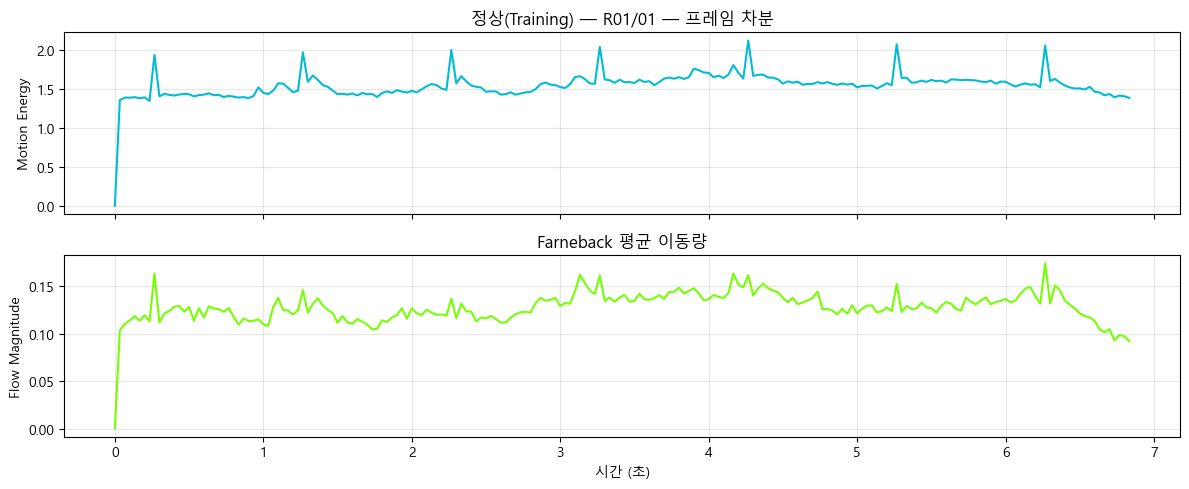

In [5]:
def compute_motion_energy(frames: list[np.ndarray]) -> np.ndarray:
    """
    프레임 시퀀스에서 Motion Energy 시계열을 계산한다.
    산업 설비: 한 사이클 내 동작 peak / 정지 trough 패턴이 반복된다.
    """
    energies = []
    for i in range(len(frames) - 1):
        # 컬러 대신 그레이스케일 — 밝기 변화만 측정해 연산량·노이즈 감소
        g0 = cv2.cvtColor(frames[i], cv2.COLOR_BGR2GRAY)
        g1 = cv2.cvtColor(frames[i + 1], cv2.COLOR_BGR2GRAY)
        # |F(t+1)-F(t)| 픽셀 평균 → 프레임 간 전역 움직임 강도 1 scalar
        energies.append(float(np.mean(cv2.absdiff(g0, g1))))
    return np.array(energies)


def compute_flow_magnitude_mean(frames: list[np.ndarray]) -> np.ndarray:
    """Farneback Optical Flow magnitude 평균 — Motion Energy 보완 지표."""
    mags = []
    for i in range(len(frames) - 1):
        g0 = cv2.cvtColor(frames[i], cv2.COLOR_BGR2GRAY)
        g1 = cv2.cvtColor(frames[i + 1], cv2.COLOR_BGR2GRAY)
        # Farneback: dense flow — 픽셀별 (dx, dy) 추정
        flow = cv2.calcOpticalFlowFarneback(g0, g1, None, 0.5, 3, 15, 3, 5, 1.2, 0)
        mag, _ = cv2.cartToPolar(flow[..., 0], flow[..., 1])
        mags.append(float(np.mean(mag)))
    return np.array(mags)


def plot_motion_signals(
    motion: np.ndarray,
    flow_mag: np.ndarray,
    *,
    title: str,
    fps: float = 30.0,
    save_path: Path | None = None,
) -> None:
    """Motion Energy / Flow magnitude를 시간(초) 축으로 시각화."""
    t = np.arange(len(motion)) / fps
    fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
    axes[0].plot(t, motion, color="#00bcd4", lw=1.5)
    axes[0].set_ylabel("Motion Energy")
    axes[0].set_title(f"{title} — 프레임 차분")
    axes[0].grid(alpha=0.3)

    axes[1].plot(t, flow_mag, color="#76ff03", lw=1.5)
    axes[1].set_xlabel("시간 (초)")
    axes[1].set_ylabel("Flow Magnitude")
    axes[1].set_title("Farneback 평균 이동량")
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"저장: {save_path}")
    plt.show()


# 정상(train) 클립 기준 Motion Energy·Flow 시계열 생성 및 시각화
train_motion = compute_motion_energy(train_frames)
train_flow = compute_flow_magnitude_mean(train_frames)
plot_motion_signals(
    train_motion, train_flow,
    title=f"정상(Training) — {train_clip.device}/{train_clip.clip_id}",
    save_path=FIG_DIR / "01_motion_energy_train.png",
)


## 3. 주기(Period) 추정 — Autocorrelation & FFT

### 이 단계에서 쓰는 기술

**Autocorrelation (자기상관)**  
Motion Energy 시계열을 자기 자신과 lag(지연)만큼 밀어 비교합니다.  
**lag = T**에서 상관이 다시 peak → “T 프레임마다 비슷한 패턴이 반복” → **1사이클 = T frames**.

- `scipy.signal.correlate`로 계산
- lag=0 근처 peak는 trivial하므로 `min_lag` 이후 구간에서 최대값 탐색

**FFT (고속 푸리에 변환)**  
시계열 전체를 주파수 영역으로 보면, **가장 강한 주파수 f**가 dominant cycle frequency입니다.  
주기(초) = `1/f`. Autocorr 결과와 **대략 일치**하면 추정 신뢰도가 높습니다.

- `scipy.fft.rfft` / `rfftfreq`
- DC(0 Hz) 성분은 제외하고 최대 스펙트럼 bin 선택

**시각화**  
상단: Motion Energy + 추정 주기마다 수직선  
하단: Autocorrelation 곡선 + peak lag 표시

IPAD 논문 기준 설비 1사이클은 보통 **5~30초**, 설비 내에서는 **거의 고정**(이상 시 길이·강도 변화).


[주기 추정] Autocorr: 30 frames ≈ 1.00s
            FFT    : 6.87s (0.1456 Hz)
저장: output_ipad\figures\02_period_analysis.png


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_20208\791843520.py:79: UserWarning: Glyph 8776 (\N{ALMOST EQUAL TO}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_20208\791843520.py:81: UserWarning: Glyph 8776 (\N{ALMOST EQUAL TO}) missing from font(s) Malgun Gothic.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
C:\Users\storm\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8776 (\N{ALMOST EQUAL TO}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


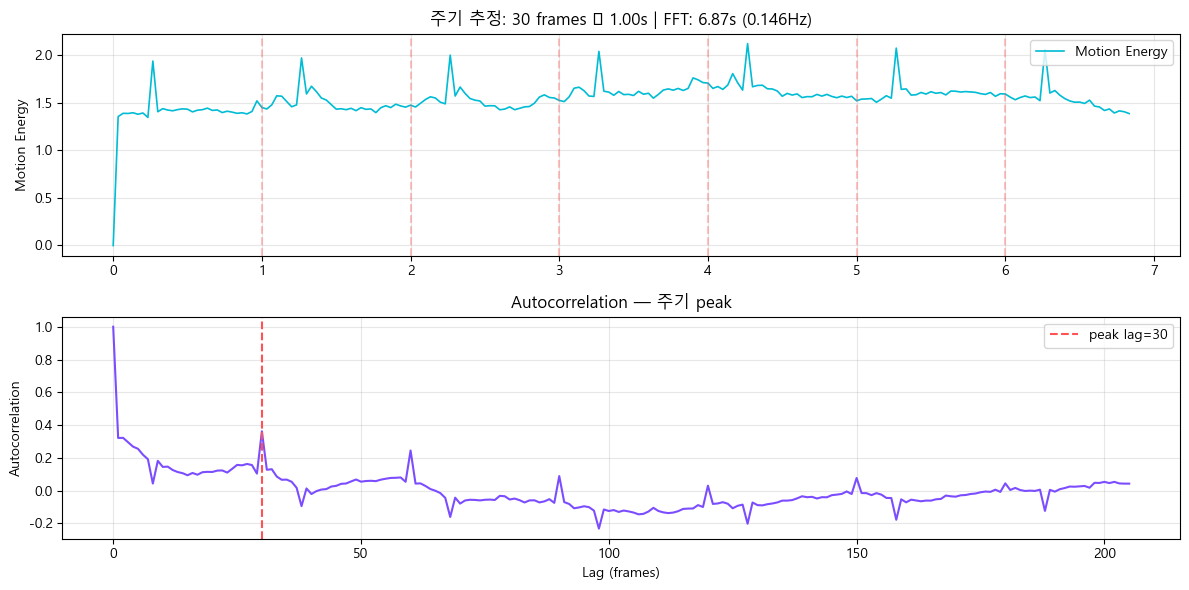

In [6]:
def estimate_period_autocorr(
    series: np.ndarray,
    min_lag: int = 5,
    max_lag: int | None = None,
) -> tuple[int, np.ndarray]:
    """
    Autocorrelation으로 주기(프레임 단위)를 추정한다.
    반환: (estimated_period_frames, autocorr_array)
    """
    # DC 성분 제거 — 평균 에너지 수준과 무관하게 주기 peak만 보려면 필수
    x = series - series.mean()
    if max_lag is None:
        max_lag = min(len(x) // 2, 900)  # 최대 ~30초@30fps
    # full correlate 후 양의 lag 절반만 사용
    ac = sp_signal.correlate(x, x, mode="full")
    ac = ac[len(ac) // 2 :]
    ac = ac / (ac[0] + 1e-8)  # lag=0에서 1로 정규화

    # lag=0 근처( min_lag 미만 )는 trivial peak 이므로 제외하고 탐색
    search_end = min(max_lag, len(ac) - 1)
    segment = ac[min_lag:search_end]
    if len(segment) == 0:
        return min_lag, ac
    peak_lag = int(np.argmax(segment)) + min_lag
    return peak_lag, ac


def estimate_period_fft(series: np.ndarray, fps: float = 30.0) -> tuple[float, float]:
    """
    FFT dominant frequency로 주기(초)를 추정한다.
    반환: (period_sec, dominant_freq_hz)
    """
    x = series - series.mean()
    spec = np.abs(rfft(x))
    freqs = rfftfreq(len(x), d=1.0 / fps)
    # DC(0Hz) 제외
    if len(spec) <= 1:
        return float("nan"), 0.0
    idx = np.argmax(spec[1:]) + 1
    dom_f = freqs[idx]
    period = 1.0 / dom_f if dom_f > 1e-6 else float("nan")
    return period, dom_f


def plot_period_analysis(
    motion: np.ndarray,
    period_frames: int,
    ac: np.ndarray,
    fps: float = 30.0,
    *,
    save_path: Path | None = None,
) -> None:
    """Motion Energy + Autocorrelation + 주기 마커를 한 figure에 표시."""
    period_sec, dom_f = estimate_period_fft(motion, fps)
    t = np.arange(len(motion)) / fps
    lags = np.arange(len(ac))

    fig, axes = plt.subplots(2, 1, figsize=(12, 6))

    axes[0].plot(t, motion, color="#00bcd4", lw=1.2, label="Motion Energy")
    # 추정 주기마다 수직선 — 사이클 경계가 시간축과 맞는지 육안 확인
    for k in range(1, int(t[-1] / (period_frames / fps)) + 1):
        axes[0].axvline(k * period_frames / fps, color="#ff5252", alpha=0.35, ls="--")
    axes[0].set_title(
        f"주기 추정: {period_frames} frames ≈ {period_frames/fps:.2f}s "
        f"| FFT: {period_sec:.2f}s ({dom_f:.3f}Hz)"
    )
    axes[0].set_ylabel("Motion Energy")
    axes[0].legend(loc="upper right")
    axes[0].grid(alpha=0.3)

    axes[1].plot(lags[: min(900, len(lags))], ac[: min(900, len(lags))], color="#7c4dff")
    axes[1].axvline(period_frames, color="#ff5252", ls="--", label=f"peak lag={period_frames}")
    axes[1].set_xlabel("Lag (frames)")
    axes[1].set_ylabel("Autocorrelation")
    axes[1].set_title("Autocorrelation — 주기 peak")
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"저장: {save_path}")
    plt.show()


# Autocorr·FFT 두 방법으로 주기 추정 — 산업 설비는 두 값이 비슷하면 신뢰도 높음
period_frames, autocorr = estimate_period_autocorr(train_motion)
period_sec_fft, dom_freq = estimate_period_fft(train_motion)
print(f"[주기 추정] Autocorr: {period_frames} frames ≈ {period_frames/fps_assumed:.2f}s")
print(f"            FFT    : {period_sec_fft:.2f}s ({dom_freq:.4f} Hz)")

plot_period_analysis(
    train_motion, period_frames, autocorr, fps_assumed,
    save_path=FIG_DIR / "02_period_analysis.png",
)


## 4. 주기 단위 사이클 분할

### 이 단계에서 쓰는 기술

**고정 길이 슬라이싱 (`segment_cycles`)**  
추정된 주기 `period`(프레임 수)로 Motion Energy를 잘라 **사이클 0, 1, 2, …** 리스트를 만듭니다.  
마지막 `period` 미만 구간은 버립니다.

**사이클 overlay (`plot_cycle_overlay`)**  
여러 사이클의 Motion Energy 곡선을 **같은 시간축(0 ~ 1사이클)**에 겹쳐 그립니다.  
정상 설비면 곡선들이 **서로 잘 맞물리고**, 이상이 있으면 특정 사이클만 **형태가 어긋납니다**.

**키프레임 시각화 (`visualize_cycle_keyframes`)**  
한 사이클의 시작·1/4·1/2·3/4 지점 프레임을 나란히 보여, **실제 영상에서 무엇이 움직이는지** 확인합니다.

**IPAD 논문과의 연결**  
이 분할은 논문의 **Period Memory / Sliding Window** 아이디어의 기초 — “한 주기 단위로 패턴을 기억·비교한다”는 개념의 출발점입니다.


[사이클] 6개 분할 (period=30 frames)


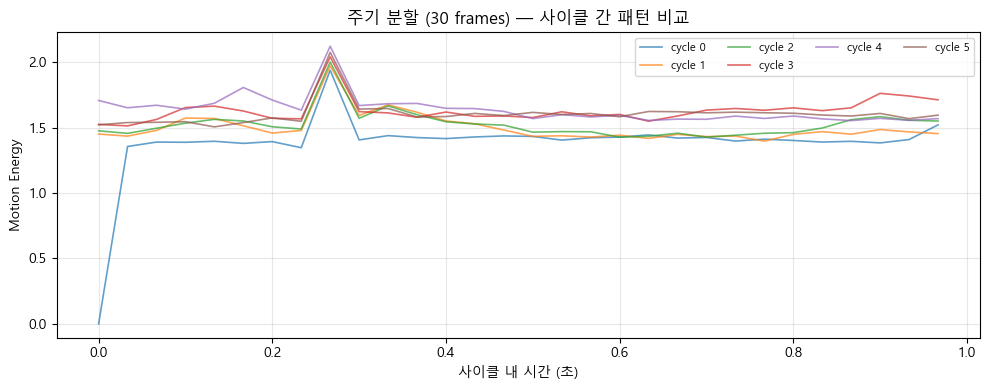

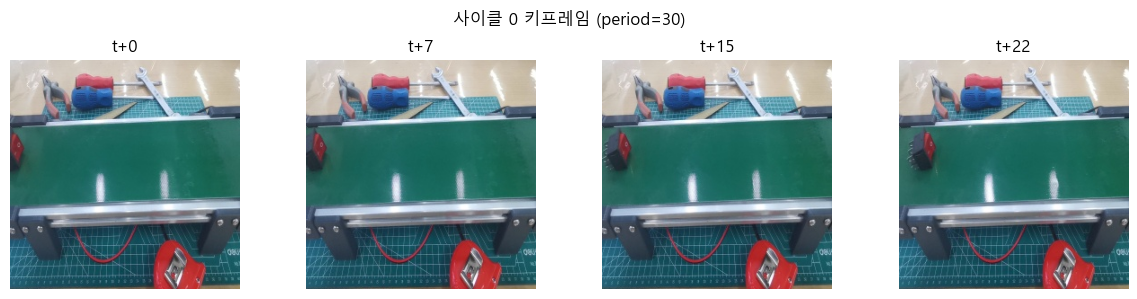

In [7]:
def segment_cycles(motion: np.ndarray, period: int) -> list[np.ndarray]:
    """Motion Energy를 주기 길이 period로 잘라 사이클 리스트 반환."""
    # 마지막 미만 period 구간은 버림 — 정확히 period 길이 사이클만 사용
    n_cycles = len(motion) // period
    return [motion[i * period : (i + 1) * period] for i in range(n_cycles)]


def plot_cycle_overlay(cycles: list[np.ndarray], period: int, fps: float = 30.0, *, save_path=None):
    """여러 사이클 Motion Energy를 한 그래프에 겹쳐 정상 반복성을 확인."""
    fig, ax = plt.subplots(figsize=(10, 4))
    t_cycle = np.arange(period) / fps
    # 최대 8개만 겹쳐 그림 — 가독성·속도
    for i, c in enumerate(cycles[:8]):
        ax.plot(t_cycle, c, alpha=0.7, lw=1.2, label=f"cycle {i}")
    ax.set_xlabel("사이클 내 시간 (초)")
    ax.set_ylabel("Motion Energy")
    ax.set_title(f"주기 분할 ({period} frames) — 사이클 간 패턴 비교")
    ax.legend(fontsize=8, ncol=4)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def visualize_cycle_keyframes(
    frames: list[np.ndarray],
    period: int,
    cycle_index: int = 0,
    *,
    save_path=None,
):
    """한 사이클 내 대표 프레임(시작·1/4·1/2·3/4)을 표시."""
    start = cycle_index * period
    end = min(start + period, len(frames))
    seg = frames[start:end]
    if len(seg) < 2:
        return
    # 사이클을 4등분한 시점의 프레임 — 동작 단계 육안 확인용
    idxs = [0, len(seg)//4, len(seg)//2, 3*len(seg)//4]
    fig, axes = plt.subplots(1, 4, figsize=(12, 3))
    for ax, fi in zip(axes, idxs):
        ax.imshow(cv2.cvtColor(seg[fi], cv2.COLOR_BGR2RGB))
        ax.set_title(f"t+{fi}")
        ax.axis("off")
    fig.suptitle(f"사이클 {cycle_index} 키프레임 (period={period})", fontsize=12)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


cycles = segment_cycles(train_motion, period_frames)
print(f"[사이클] {len(cycles)}개 분할 (period={period_frames} frames)")
plot_cycle_overlay(cycles, period_frames, fps_assumed, save_path=FIG_DIR / "03_cycle_overlay.png")
visualize_cycle_keyframes(train_frames, period_frames, cycle_index=0, save_path=FIG_DIR / "04_cycle_keyframes.png")


## 5. Optical Flow — 설비 부품 이동

### 이 단계에서 쓰는 기술

**Farneback Dense Optical Flow**  
인접 두 프레임(그레이스케일)에서 **모든 픽셀**의 이동 벡터 `(dx, dy)`를 추정합니다.  
`cv2.calcOpticalFlowFarneback(g0, g1, …)` — 01 Temporal Vision에서 다룬 dense flow와 동일 계열.

**왜 peak 구간인가?**  
Motion Energy가 **최대**인 순간 = 설비가 가장 활발히 움직일 때 → flow 패턴이 **가장 뚜렷**합니다.

**HSV 컬러맵 (`flow_to_hsv`)**  
- **Hue(색상)** → 이동 **방향**
- **Value(밝기)** → 이동 **속력**

컨베이어(→), 리프트(↑↓)처럼 **반복되는 이동 방향**을 한 장의 pseudo-color 이미지로 볼 수 있습니다.

**이상과의 관계**  
속도 저하, 역방향 이동, 특정 ROI만 움직임 등은 flow HSV **색·밝기 분포 변화**로 나타날 수 있습니다.


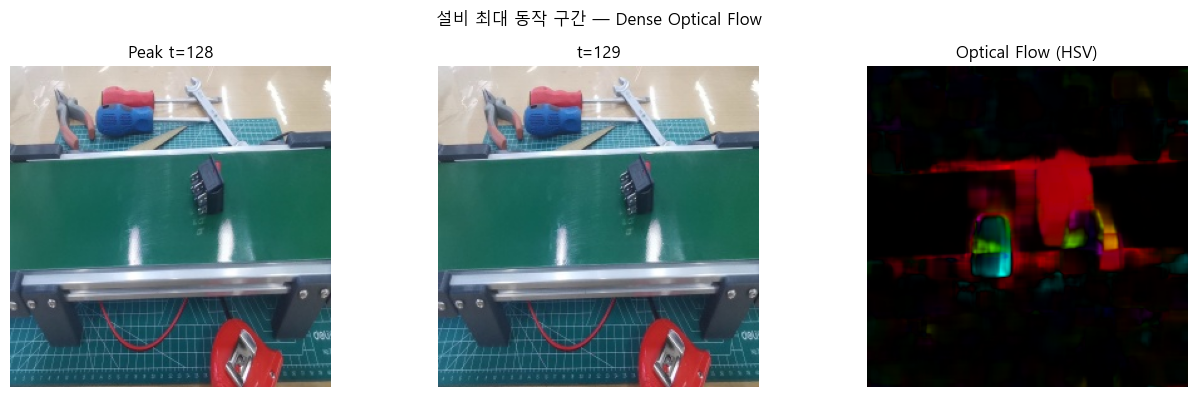

In [8]:
def flow_to_hsv(flow: np.ndarray) -> np.ndarray:
    """
    Optical Flow (dx, dy) → HSV 컬러맵.
    Hue=이동 방향, Value=속력 — dense flow 패턴을 한 장으로 요약.
    """
    mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])
    hsv = np.zeros((flow.shape[0], flow.shape[1], 3), dtype=np.uint8)
    hsv[..., 0] = (ang * 180 / np.pi / 2).astype(np.uint8)
    hsv[..., 1] = 255
    hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)


def visualize_peak_motion_flow(
    frames: list[np.ndarray],
    motion: np.ndarray,
    *,
    save_path: Path | None = None,
) -> None:
    """Motion Energy가 최대인 구간에서 Optical Flow HSV 시각화."""
    # Motion Energy peak = 설비가 가장 많이 움직인 순간
    peak_idx = int(np.argmax(motion))
    prev_bgr, next_bgr = frames[peak_idx], frames[peak_idx + 1]

    g0 = cv2.cvtColor(prev_bgr, cv2.COLOR_BGR2GRAY)
    g1 = cv2.cvtColor(next_bgr, cv2.COLOR_BGR2GRAY)
    flow = cv2.calcOpticalFlowFarneback(g0, g1, None, 0.5, 3, 15, 3, 5, 1.2, 0)
    flow_hsv = flow_to_hsv(flow)

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    axes[0].imshow(cv2.cvtColor(prev_bgr, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Peak t={peak_idx}"); axes[0].axis("off")
    axes[1].imshow(cv2.cvtColor(next_bgr, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f"t={peak_idx+1}"); axes[1].axis("off")
    axes[2].imshow(cv2.cvtColor(flow_hsv, cv2.COLOR_BGR2RGB))
    axes[2].set_title("Optical Flow (HSV)"); axes[2].axis("off")
    fig.suptitle("설비 최대 동작 구간 — Dense Optical Flow", fontsize=12)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


visualize_peak_motion_flow(
    train_frames, train_motion,
    save_path=FIG_DIR / "05_optical_flow_peak.png",
)


## 6. 정상 vs 이상 — 시간 패턴 편차

### 이 단계에서 쓰는 기술

**사이클 단위 요약 (`cycle_energy_profile`)**  
각 사이클 Motion Energy의 **평균** 하나로 사이클 전체를 대표합니다.  
프레임 수백 장 → 사이클 1개 = scalar 1개로 **압축**합니다.

**Z-score 이상 점수**  
1. train(정상) 사이클 평균 에너지로 **μ, σ** 계산  
2. test 각 사이클에 `z = (x − μ) / σ`  
3. **|z| > 2** → train에서 통계적으로 드문 패턴 → **이상 후보** (빨간 bar)

**train / test 클립 비교**  
- `training/`: IPAD 논문 기준 **정상** 위주  
- `testing/`: **이상 구간 포함** 가능  

규칙 기반 baseline이지만, 딥러닝 VAD의 “정상 분포 대비 reconstruction error” 개념과 **직관적으로 대응**합니다.

**IPAD VAD (참고)**  
논문 본 모델은 reconstruction + **period classification** 등을 사용합니다. 본 실습은 그 전 단계로 **Motion Energy Z-score**를 구현합니다.


저장: output_ipad\figures\06_motion_energy_test.png


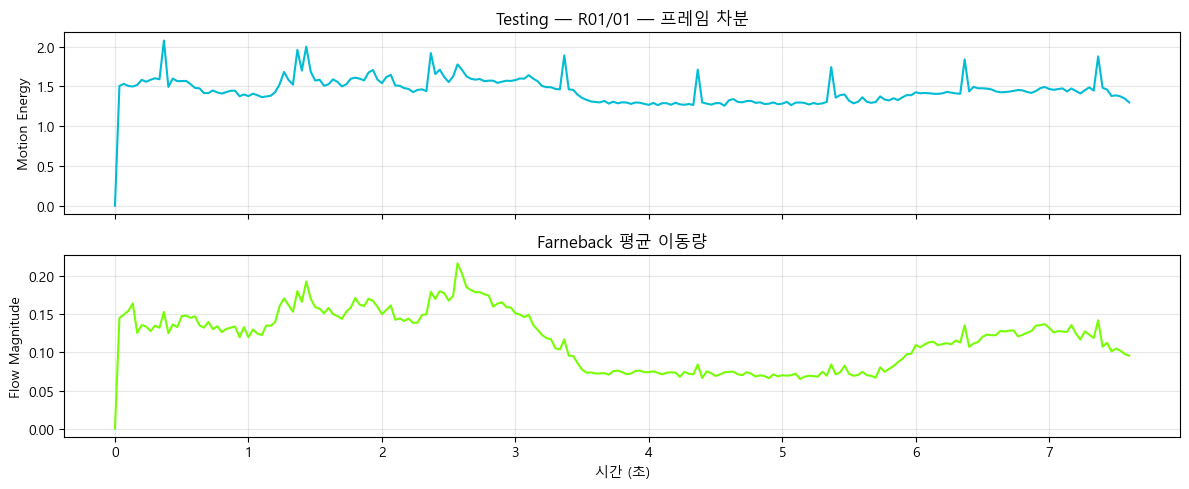

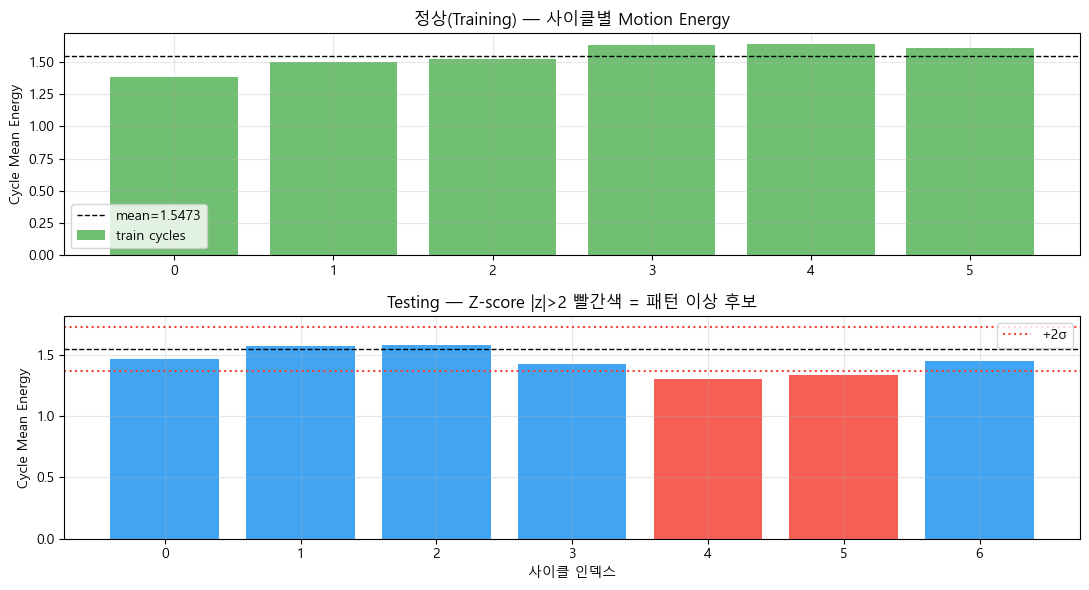

[이상 후보 사이클] indices=[4, 5] (|Z|>2)


In [9]:
def cycle_energy_profile(motion: np.ndarray, period: int) -> np.ndarray:
    """각 사이클의 평균 Motion Energy → 사이클 단위 시계열."""
    cycles = segment_cycles(motion, period)
    return np.array([c.mean() for c in cycles])


def compare_train_test_patterns(
    train_motion: np.ndarray,
    test_motion: np.ndarray,
    period: int,
    fps: float = 30.0,
    *,
    save_path=None,
) -> None:
    """
    정상(train) 사이클 에너지 분포 vs 테스트(test) 사이클 에너지를 비교한다.
    테스트에서 baseline을 크게 벗어나는 사이클 = 잠재 이상 구간.
    """
    train_cycle_e = cycle_energy_profile(train_motion, period)
    test_cycle_e = cycle_energy_profile(test_motion, period)

    # train 사이클 평균·표준편차 = 정상 baseline
    mu, sigma = train_cycle_e.mean(), train_cycle_e.std() + 1e-8
    z_scores = (test_cycle_e - mu) / sigma

    fig, axes = plt.subplots(2, 1, figsize=(11, 6))
    axes[0].bar(range(len(train_cycle_e)), train_cycle_e, color="#4caf50", alpha=0.8, label="train cycles")
    axes[0].axhline(mu, color="k", ls="--", lw=1, label=f"mean={mu:.4f}")
    axes[0].set_ylabel("Cycle Mean Energy")
    axes[0].set_title("정상(Training) — 사이클별 Motion Energy")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # |z|>2: train 분포 대비 통계적으로 드문 test 사이클 → 이상 후보
    colors = ["#f44336" if abs(z) > 2 else "#2196f3" for z in z_scores]
    axes[1].bar(range(len(test_cycle_e)), test_cycle_e, color=colors, alpha=0.85)
    axes[1].axhline(mu, color="k", ls="--", lw=1)
    axes[1].axhline(mu + 2*sigma, color="#f44336", ls=":", label="+2σ")
    axes[1].axhline(mu - 2*sigma, color="#f44336", ls=":")
    axes[1].set_xlabel("사이클 인덱스")
    axes[1].set_ylabel("Cycle Mean Energy")
    axes[1].set_title("Testing — Z-score |z|>2 빨간색 = 패턴 이상 후보")
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

    flagged = np.where(np.abs(z_scores) > 2)[0]
    print(f"[이상 후보 사이클] indices={flagged.tolist()} (|Z|>2)")


if test_clip is not None:
    # test 클립: 이상·정상 혼재 가능 — train baseline과 비교
    test_frames = read_frames_bgr(test_clip)
    test_motion = compute_motion_energy(test_frames)
    plot_motion_signals(
        test_motion, compute_flow_magnitude_mean(test_frames),
        title=f"Testing — {test_clip.device}/{test_clip.clip_id}",
        save_path=FIG_DIR / "06_motion_energy_test.png",
    )
    compare_train_test_patterns(
        train_motion, test_motion, period_frames, fps_assumed,
        save_path=FIG_DIR / "07_train_test_cycle_compare.png",
    )
else:
    print("[안내] testing 클립 없음 — 정상 클립만 분석 완료")

# frame_labels npy가 있으면 shape만 출력 (샘플 zip에는 없을 수 있음)
labels = try_load_anomaly_labels(ipad_root, train_clip.device)
if labels is not None:
    print(f"[라벨] shape/type: {getattr(labels, 'shape', type(labels))}")


## 7. STFT 스펙트로그램 — 시간-주파수 패턴

### 이 단계에서 쓰는 기술

**STFT (Short-Time Fourier Transform)**  
긴 시계열을 **짧은 윈도우**로 잘라 각 구간마다 FFT → “**그 순간** 어떤 주파수가 강한가”를 2D 히트맵으로 표현합니다.  
`scipy.signal.stft(motion, fs=fps, nperseg=…, noverlap=…)`

**Autocorr/FFT와의 차이**  
| 방법 | 보는 것 |
|------|---------|
| Autocorr / FFT | 영상 **전체**의 대표 주기 (global) |
| STFT | **시간 구간별** 주파수 변화 (local) |

**스펙트로그램 읽는 법**  
- **수평 stripe**가 안정적 → 주기가 **일정**
- stripe **위치가 점점 변함** → **주기 drift** (사이클 길이가 서서히 변하는 이상)
- 특정 시간만 stripe가 **흐릿·사라짐** → **과도(transient)** 또는 동작 중단

**코드 포인트**  
`nperseg`(윈도우 길이), `noverlap`(75%)로 시간·주파수 해상도 trade-off.  
cyan 점선 = Autocorr로 구한 **전역 주기 주파수** 참조.


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_20208\2977752951.py:41: UserWarning: Glyph 8776 (\N{ALMOST EQUAL TO}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_20208\2977752951.py:43: UserWarning: Glyph 8776 (\N{ALMOST EQUAL TO}) missing from font(s) Malgun Gothic.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")


저장: output_ipad\figures\08_stft_train.png


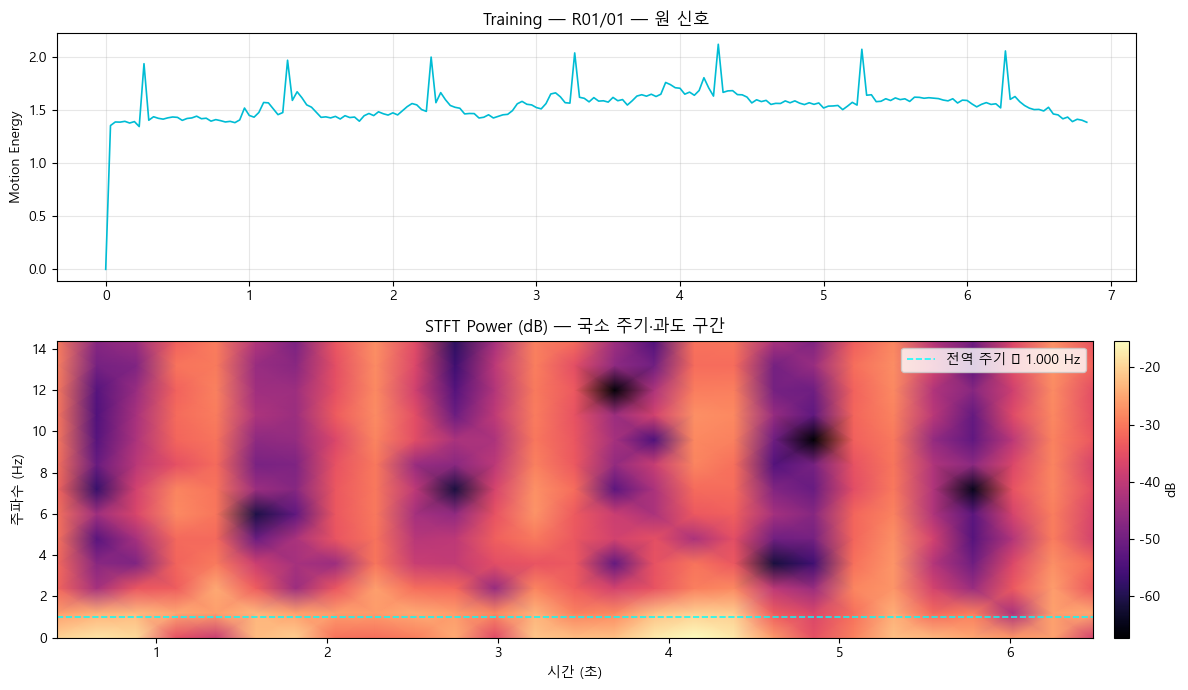

저장: output_ipad\figures\09_stft_test.png


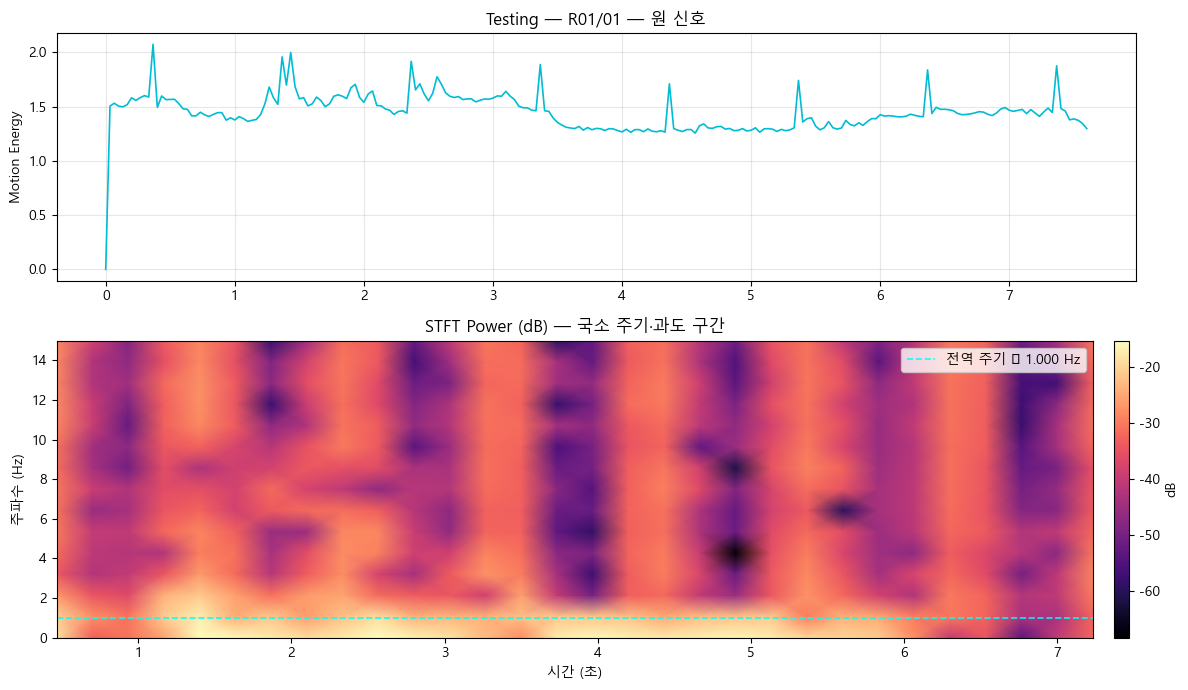

In [10]:
def plot_motion_stft(
    motion: np.ndarray,
    *,
    fps: float = 30.0,
    title: str = "Motion Energy STFT",
    save_path: Path | None = None,
) -> None:
    """
    Motion Energy STFT 스펙트로그램.
    산업 설비: 수평 stripe = 안정 주기, stripe 간격 변화 = 주기 drift 후보.
    """
    x = motion - motion.mean()
    # 윈도우 길이: 너무 짧으면 주파수 해상도↓, 너무 길면 시간 해상도↓
    nperseg = min(64, max(16, len(x) // 8))
    noverlap = nperseg * 3 // 4  # 75% overlap — 시간축 매끄럽게
    freqs, times, zxx = sp_signal.stft(
        x, fs=fps, nperseg=nperseg, noverlap=noverlap, boundary=None
    )
    power = np.abs(zxx) ** 2
    power_db = 10 * np.log10(power + 1e-12)  # log 스케일로 약한 성분도 보이게

    fig, axes = plt.subplots(2, 1, figsize=(12, 7), gridspec_kw={"height_ratios": [1, 1.2]})
    t_sig = np.arange(len(motion)) / fps
    axes[0].plot(t_sig, motion, color="#00bcd4", lw=1.2)
    axes[0].set_ylabel("Motion Energy")
    axes[0].set_title(f"{title} — 원 신호")
    axes[0].grid(alpha=0.3)

    im = axes[1].pcolormesh(times, freqs, power_db, shading="gouraud", cmap="magma")
    axes[1].set_xlabel("시간 (초)")
    axes[1].set_ylabel("주파수 (Hz)")
    axes[1].set_title("STFT Power (dB) — 국소 주기·과도 구간")
    if freqs[-1] > 0:
        # Autocorr로 구한 전역 주기를 Hz로 변환해 참조선 표시
        dom_line = 1.0 / (period_frames / fps) if period_frames > 0 else dom_freq
        if dom_line > 0 and dom_line <= freqs[-1]:
            axes[1].axhline(dom_line, color="cyan", ls="--", lw=1.2, alpha=0.9,
                            label=f"전역 주기 ≈ {dom_line:.3f} Hz")
            axes[1].legend(loc="upper right")
    fig.colorbar(im, ax=axes[1], fraction=0.02, pad=0.02, label="dB")
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"저장: {save_path}")
    plt.show()


plot_motion_stft(
    train_motion,
    fps=fps_assumed,
    title=f"Training — {train_clip.device}/{train_clip.clip_id}",
    save_path=FIG_DIR / "08_stft_train.png",
)
if test_clip is not None:
    plot_motion_stft(
        test_motion,
        fps=fps_assumed,
        title=f"Testing — {test_clip.device}/{test_clip.clip_id}",
        save_path=FIG_DIR / "09_stft_test.png",
    )


## 8. DTW 사이클 정렬 — Dynamic Time Warping

### 이 단계에서 쓰는 기술

**DTW (Dynamic Time Warping)**  
두 시계열의 **길이·속도가 달라도** 비선형으로 시간축을 맞춰(min-cost path) 유사도를 측정합니다.  
동적 프로그래밍 테이블 `d[i,j]` — insert / delete / match 중 최소 누적 비용.

**Cycle Template**  
정상 train 사이클들을 z-score 정규화한 뒤, **픽셀(시간)별 median** → outlier에 강한 **기준 곡선**.

**DTW Distance = 이상 점수**  
각 test 사이클 ↔ template 거리가 크면 **곡선 형태**가 다름 → 이상 후보.  
train DTW 분포 대비 **|z|>2** bar로 표시.

**Z-score와의 차이**  
| 방법 | 비교 대상 |
|------|-----------|
| Z-score (앞 단계) | 사이클 **평균 에너지** 1개 숫자 |
| DTW | 사이클 **전체 곡선 shape** |

peak가 몇 프레임 밀려도 DTW는 **warp**로 흡수 — L2 거리보다 산업 주기 패턴에 적합합니다.


[DTW 이상 후보 사이클] test indices=[3] (|Z|>2, dist=[19.84])
저장: output_ipad\figures\10_dtw_cycle_analysis.png


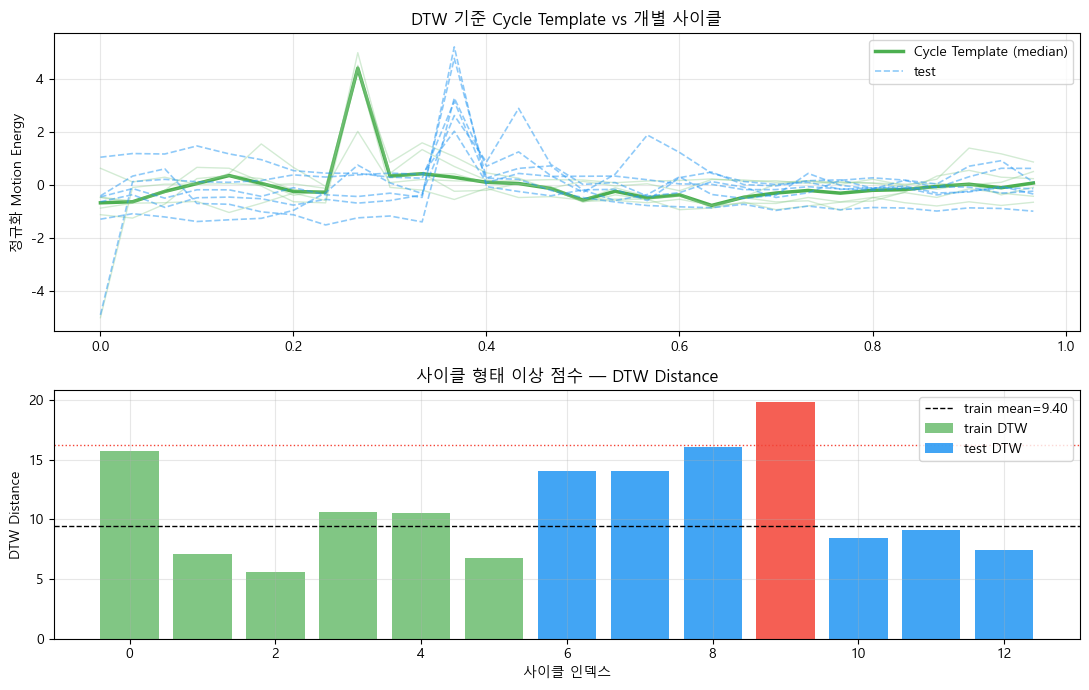

In [11]:
def dtw_distance(a: np.ndarray, b: np.ndarray) -> float:
    """
    Dynamic Time Warping 누적 거리 (O(n·m)).
    사이클 길이가 같아도 peak 위치가 밀리면 L2 거리보다 DTW가 robust.
    """
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    n, m = len(a), len(b)
    # DP 테이블: d[i,j] = a[:i]와 b[:j] 정렬 최소 비용
    d = np.full((n + 1, m + 1), np.inf)
    d[0, 0] = 0.0
    for i in range(1, n + 1):
        ai = a[i - 1]
        for j in range(1, m + 1):
            cost = abs(ai - b[j - 1])
            # insert / delete / match 중 최소 경로
            d[i, j] = cost + min(d[i - 1, j], d[i, j - 1], d[i - 1, j - 1])
    return float(d[n, m])


def normalize_cycle(cycle: np.ndarray) -> np.ndarray:
    """진폭·오프셋 차이를 줄이기 위해 z-score 정규화."""
    c = cycle.astype(np.float64)
    return (c - c.mean()) / (c.std() + 1e-8)


def build_cycle_template(cycles: list[np.ndarray]) -> np.ndarray:
    """정상 사이클들의 정규화 후 element-wise median → robust template."""
    # mean 대신 median: outlier 사이클 1~2개 있어도 template이 안정적
    normed = np.stack([normalize_cycle(c) for c in cycles if len(c) > 0], axis=0)
    return np.median(normed, axis=0)


def dtw_anomaly_scores(cycles: list[np.ndarray], template: np.ndarray) -> np.ndarray:
    """각 사이클과 template 간 DTW 거리 배열."""
    tpl = normalize_cycle(template)
    scores = []
    for c in cycles:
        if len(c) == 0:
            scores.append(np.nan)
            continue
        c_norm = normalize_cycle(c)
        # 길이 차이 허용: DTW가 비선형 warp
        scores.append(dtw_distance(c_norm, tpl))
    return np.array(scores)


def plot_dtw_analysis(
    train_cycles: list[np.ndarray],
    test_cycles: list[np.ndarray] | None,
    template: np.ndarray,
    fps: float = 30.0,
    *,
    save_path: Path | None = None,
) -> None:
    """Template + train/test DTW 거리 + |z|>2 이상 후보 표시."""
    train_dtw = dtw_anomaly_scores(train_cycles, template)
    mu, sigma = train_dtw.mean(), train_dtw.std() + 1e-8

    fig, axes = plt.subplots(2, 1, figsize=(11, 7), gridspec_kw={"height_ratios": [1.2, 1]})
    t_tpl = np.arange(len(template)) / fps
    axes[0].plot(t_tpl, template, color="#4caf50", lw=2.5, label="Cycle Template (median)")
    for i, c in enumerate(train_cycles[:6]):
        axes[0].plot(t_tpl, normalize_cycle(c), alpha=0.35, lw=1, color="#81c784")
    if test_cycles:
        for i, c in enumerate(test_cycles[:6]):
            axes[0].plot(
                np.arange(len(c)) / fps, normalize_cycle(c),
                alpha=0.5, lw=1.2, ls="--", color="#2196f3", label="test" if i == 0 else None,
            )
    axes[0].set_ylabel("정규화 Motion Energy")
    axes[0].set_title("DTW 기준 Cycle Template vs 개별 사이클")
    axes[0].legend(loc="upper right")
    axes[0].grid(alpha=0.3)

    axes[1].bar(range(len(train_dtw)), train_dtw, color="#4caf50", alpha=0.7, label="train DTW")
    if test_cycles is not None and len(test_cycles) > 0:
        test_dtw = dtw_anomaly_scores(test_cycles, template)
        z = (test_dtw - mu) / sigma
        colors = ["#f44336" if abs(v) > 2 else "#2196f3" for v in z]
        offset = len(train_dtw)
        axes[1].bar(
            range(offset, offset + len(test_dtw)), test_dtw,
            color=colors, alpha=0.85, label="test DTW",
        )
        flagged = np.where(np.abs(z) > 2)[0]
        print(f"[DTW 이상 후보 사이클] test indices={flagged.tolist()} (|Z|>2, dist={test_dtw[flagged].round(3).tolist() if len(flagged) else []})")
    axes[1].axhline(mu, color="k", ls="--", lw=1, label=f"train mean={mu:.2f}")
    axes[1].axhline(mu + 2 * sigma, color="#f44336", ls=":", lw=1)
    axes[1].set_xlabel("사이클 인덱스")
    axes[1].set_ylabel("DTW Distance")
    axes[1].set_title("사이클 형태 이상 점수 — DTW Distance")
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"저장: {save_path}")
    plt.show()


# train 정상 사이클로 template 구축 → test 사이클과 형태 거리 비교
cycle_template = build_cycle_template(cycles)
test_cycles = segment_cycles(test_motion, period_frames) if test_clip is not None else None
plot_dtw_analysis(
    cycles, test_cycles, cycle_template, fps_assumed,
    save_path=FIG_DIR / "10_dtw_cycle_analysis.png",
)


## 9. CUSUM & 주기 Drift — 순차 이상·국소 주기 변화

### 이 단계에서 쓰는 기술

**CUSUM (Cumulative Sum)**  
Motion Energy가 train baseline(평균)에서 **한쪽으로 계속 벗어나면** 누적합 `S+`, `S−`가 threshold를 넘습니다.  
→ **change-point** — “언제부터 패턴이 달라졌는지” **프레임 단위** 시점.

- `drift`: 작은 흔들림 무시 (baseline의 2%)
- `threshold`: alarm 기준 (코드: 5.0)

**Rolling Period Estimate**  
전체가 아닌 **슬라이딩 윈도우** 안에서 Autocorr peak → **국소 주기(초)** 시계열.  
전역 주기(녹색 점선)에서 **벗어나는 구간** = 주기 **연장/단축** 이상 단서.

**3단 subplot**  
1. Motion Energy + alarm 수직선  
2. S+, S− 누적곡선  
3. 시간에 따른 국소 주기

프레임 CUSUM + 주기 drift를 함께 보면 **언제·어떤 방식**으로 패턴이 깨졌는지 시간축에 매핑할 수 있습니다.


저장: output_ipad\figures\11_cusum_drift_train.png


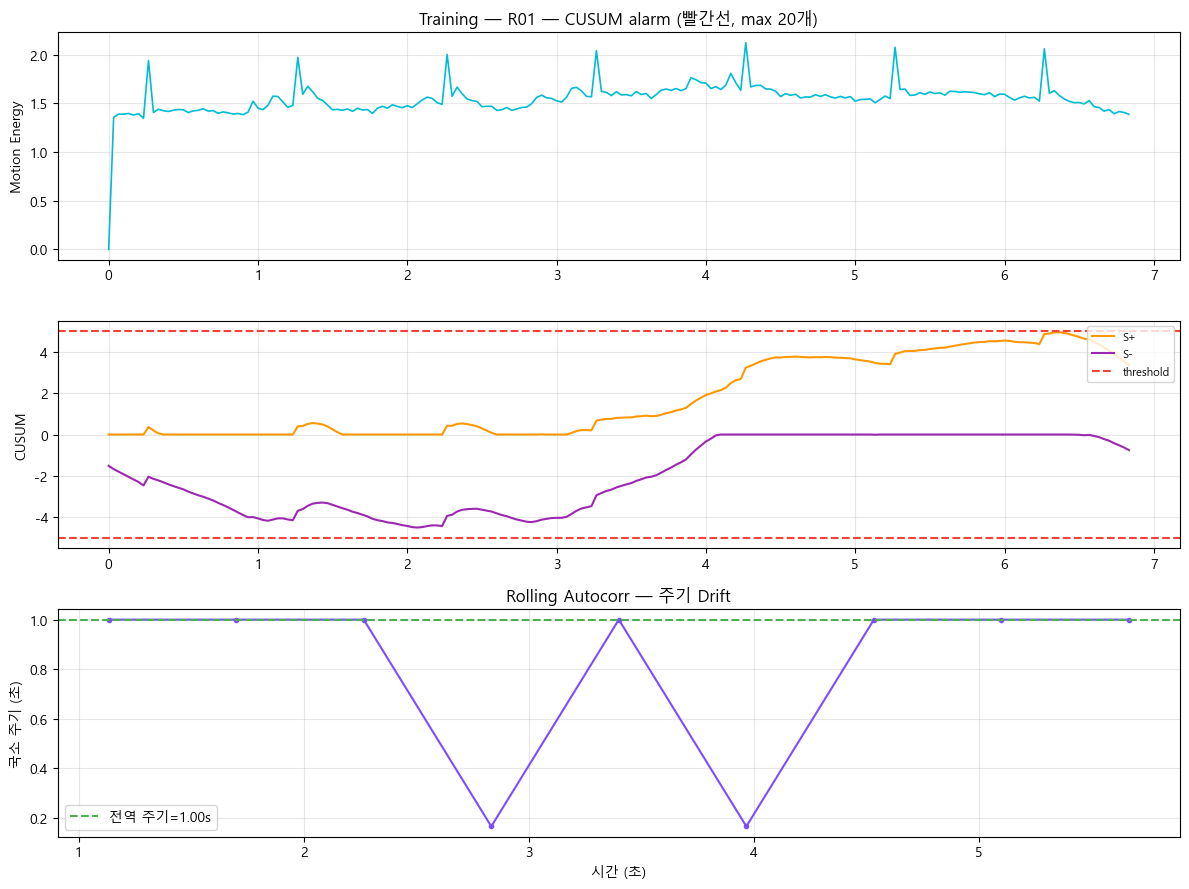

[CUSUM] alarm frames (first 15): [] → sec=[]
저장: output_ipad\figures\12_cusum_drift_test.png


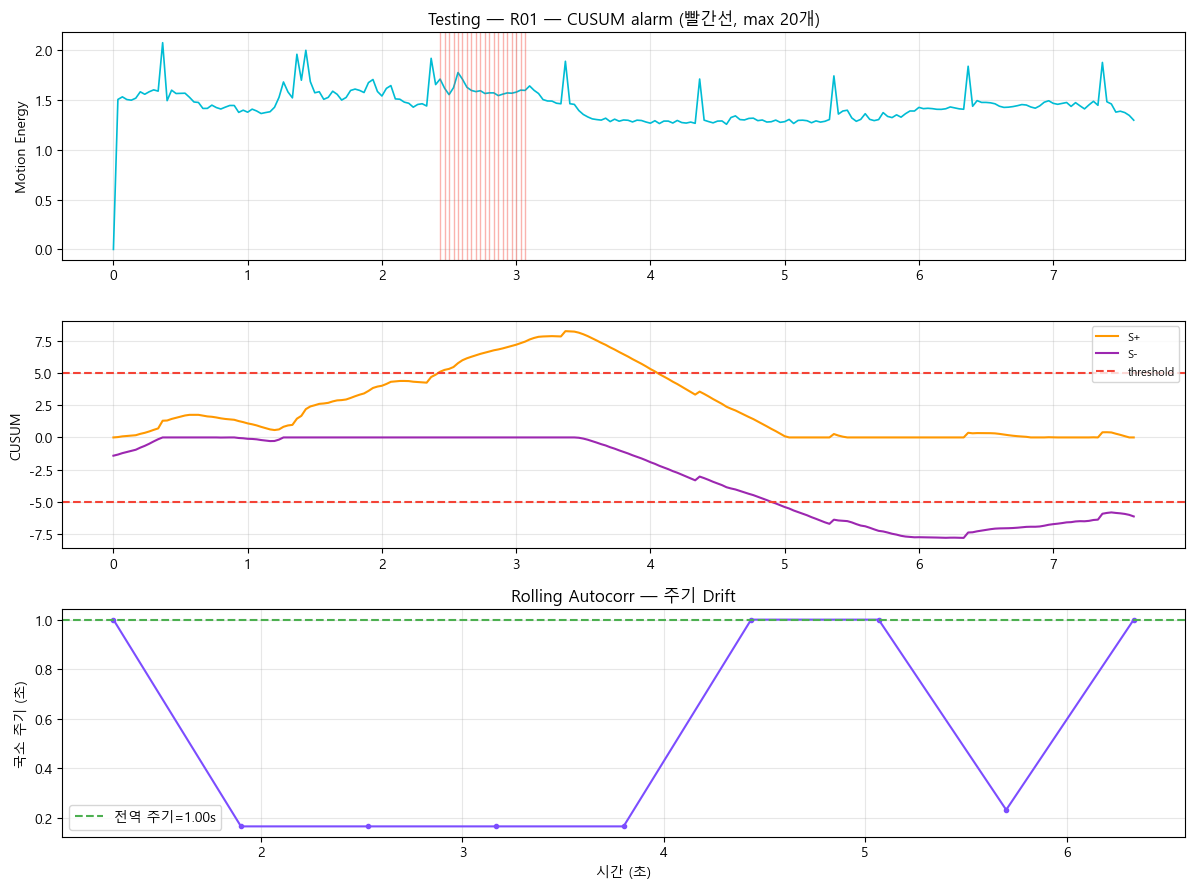

[CUSUM] alarm frames (first 15): [73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87] → sec=[2.43, 2.47, 2.5, 2.53, 2.57, 2.6, 2.63, 2.67, 2.7, 2.73, 2.77, 2.8, 2.83, 2.87, 2.9]


In [12]:
def cusum_detect(
    series: np.ndarray,
    *,
    target: float | None = None,
    drift: float = 0.0,
    threshold: float = 5.0,
) -> tuple[np.ndarray, np.ndarray, list[int]]:
    """
    양방향 CUSUM — Motion Energy 잔차의 누적합으로 change-point 탐지.
    반환: (S_pos, S_neg, alarm_indices)
    """
    x = series.astype(np.float64)
    # target: 정상 baseline (None이면 전체 평균 사용)
    mu = float(x.mean()) if target is None else target
    r = x - mu
    s_pos = np.zeros(len(r))
    s_neg = np.zeros(len(r))
    alarms: list[int] = []
    for i, val in enumerate(r):
        # S+: baseline보다 지속적으로 큰 편차 누적
        s_pos[i] = max(0.0, (s_pos[i - 1] if i else 0.0) + val - drift)
        # S-: baseline보다 지속적으로 작은 편차 누적
        s_neg[i] = min(0.0, (s_neg[i - 1] if i else 0.0) + val + drift)
        if s_pos[i] > threshold or abs(s_neg[i]) > threshold:
            alarms.append(i)
    return s_pos, s_neg, alarms


def rolling_period_estimate(
    motion: np.ndarray,
    *,
    window: int,
    min_lag: int = 5,
    step: int | None = None,
) -> tuple[np.ndarray, np.ndarray]:
    """
    슬라이딩 윈도우 Autocorr peak → 시간에 따른 국소 주기(frames) 추정.
    """
    step = step or max(1, window // 4)
    centers, periods = [], []
    for start in range(0, len(motion) - window, step):
        seg = motion[start : start + window]
        p, _ = estimate_period_autocorr(seg, min_lag=min_lag, max_lag=window // 2)
        centers.append(start + window // 2)  # 윈도우 중심 시점
        periods.append(p)
    return np.array(centers), np.array(periods)


def plot_cusum_and_drift(
    motion: np.ndarray,
    *,
    fps: float = 30.0,
    global_period: int,
    title: str = "",
    save_path: Path | None = None,
) -> None:
    """CUSUM alarm + rolling period drift를 Motion Energy와 함께 시각화."""
    baseline = float(motion.mean())
    # drift=baseline의 2%: 작은 흔들림은 무시하고 지속 편차만 누적
    s_pos, s_neg, alarms = cusum_detect(motion, target=baseline, drift=0.02 * baseline, threshold=5.0)

    # rolling window ≈ 3 사이클 — 국소 주기 추정에 충분한 길이
    win = min(max(global_period * 3, 60), len(motion) // 3)
    centers, local_p = rolling_period_estimate(motion, window=win, min_lag=5)

    fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=False)
    t = np.arange(len(motion)) / fps
    axes[0].plot(t, motion, color="#00bcd4", lw=1.2)
    for a in alarms[:20]:
        axes[0].axvline(a / fps, color="#f44336", alpha=0.4, lw=1)
    axes[0].set_ylabel("Motion Energy")
    axes[0].set_title(f"{title} — CUSUM alarm (빨간선, max 20개)")
    axes[0].grid(alpha=0.3)

    axes[1].plot(t, s_pos, label="S+", color="#ff9800")
    axes[1].plot(t, s_neg, label="S-", color="#9c27b0")
    axes[1].axhline(5.0, color="#f44336", ls="--", label="threshold")
    axes[1].axhline(-5.0, color="#f44336", ls="--")
    axes[1].set_ylabel("CUSUM")
    axes[1].legend(loc="upper right", fontsize=8)
    axes[1].grid(alpha=0.3)

    t_cent = centers / fps
    axes[2].plot(t_cent, local_p / fps, color="#7c4dff", lw=1.5, marker="o", ms=3)
    axes[2].axhline(global_period / fps, color="#4caf50", ls="--",
                    label=f"전역 주기={global_period/fps:.2f}s")
    axes[2].set_xlabel("시간 (초)")
    axes[2].set_ylabel("국소 주기 (초)")
    axes[2].set_title("Rolling Autocorr — 주기 Drift")
    axes[2].legend()
    axes[2].grid(alpha=0.3)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"저장: {save_path}")
    plt.show()
    print(f"[CUSUM] alarm frames (first 15): {alarms[:15]} → sec={[round(a/fps,2) for a in alarms[:15]]}")


plot_cusum_and_drift(
    train_motion, fps=fps_assumed, global_period=period_frames,
    title=f"Training — {train_clip.device}",
    save_path=FIG_DIR / "11_cusum_drift_train.png",
)
if test_clip is not None:
    plot_cusum_and_drift(
        test_motion, fps=fps_assumed, global_period=period_frames,
        title=f"Testing — {test_clip.device}",
        save_path=FIG_DIR / "12_cusum_drift_test.png",
    )


## 10. 다변량 사이클 feature & Mahalanobis 거리

### 이 단계에서 쓰는 기술

**사이클 feature vector (9차원)**  
한 사이클을 **숫자 여러 개**로 요약합니다.

| feature | 의미 |
|---------|------|
| mean_E, std_E, max_E | 에너지 수준·변동·peak |
| peak_pos | peak가 사이클 내 어디인지 (0~1) |
| spec_centroid | 주파수 에너지 중심 |
| half_ratio | 전반/후반 에너지 비 |
| AUC | 곡선 적분 — 총 움직임량 |
| flow_mean, flow_std | Optical Flow 보조 |

**Mahalanobis distance**  
train feature의 **평균·공분산**으로 다변량 정규분포를 가정하고, test 사이클까지의 **통계적 거리**를 계산합니다.  
feature 간 **상관**까지 반영 — 단순 Z-score(1차원)보다 풍부합니다.

- `reg=1e-3`: train 사이클 수가 적을 때 공분산 singular 방지

**PCA 2D scatter**  
9차원 feature를 SVD로 2D에 투영 — train(녹색) vs test(파랑) **군집 분리**를 시각화.

**이상 판정**  
train Mahalanobis 거리 분포 대비 test **+2σ 초과** 사이클을 후보로 출력.


[Mahalanobis 이상 후보] test cycle indices=[0, 1, 2, 3, 4, 5, 6] scores=[4.589, 5.787, 4.778, 5.032, 6.635, 6.063, 4.901]
저장: output_ipad\figures\13_mahalanobis.png


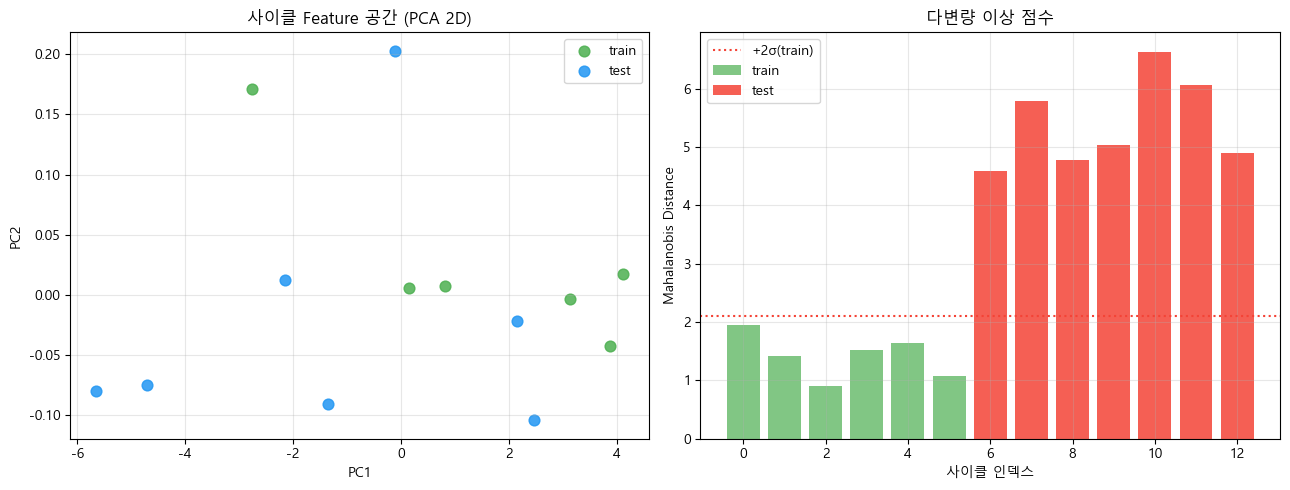

[Feature 차원] ['mean_E', 'std_E', 'max_E', 'peak_pos', 'spec_centroid', 'half_ratio', 'AUC', 'flow_mean', 'flow_std']


In [13]:
def extract_cycle_features(cycle: np.ndarray, flow_cycle: np.ndarray | None = None) -> np.ndarray:
    """
    사이클 1개에서 다변량 feature 추출 (7~8차원).
    Motion Energy 곡선 형태 + (선택) Flow magnitude 통계.
    """
    c = cycle.astype(np.float64)
    peak_idx = int(np.argmax(c))
    half = len(c) // 2
    first_half = c[:half].mean() if half > 0 else c.mean()
    second_half = c[half:].mean() if half > 0 else c.mean()
    spec = np.abs(rfft(c - c.mean()))
    freqs = rfftfreq(len(c), d=1.0)
    # spectral centroid: 에너지가 몰린 주파수 대역 — 곡선 “빠르기” 느낌
    centroid = float(np.sum(freqs * spec) / (np.sum(spec) + 1e-8))

    feats = [
        c.mean(),                                    # 평균 동작 강도
        c.std(),                                     # 사이클 내 변동성
        c.max(),                                     # peak 강도
        peak_idx / max(len(c) - 1, 1),               # peak 위치 (0~1 정규화)
        centroid,                                    # 스펙트럼 중심
        first_half / (second_half + 1e-8),           # 전·후반 에너지 비
        float(np.trapezoid(c)),                      # 곡선 적분(AUC) — 총 “움직임량”
    ]
    if flow_cycle is not None and len(flow_cycle) > 0:
        f = flow_cycle.astype(np.float64)
        feats.extend([f.mean(), f.std()])            # Flow 보조 feature
    return np.array(feats, dtype=np.float64)


def build_feature_matrix(
    motion: np.ndarray,
    period: int,
    flow: np.ndarray | None = None,
) -> np.ndarray:
    """전체 motion에서 사이클별 feature matrix (n_cycles × n_features)."""
    m_cycles = segment_cycles(motion, period)
    f_cycles = segment_cycles(flow, period) if flow is not None else [None] * len(m_cycles)
    return np.stack(
        [extract_cycle_features(mc, fc) for mc, fc in zip(m_cycles, f_cycles)],
        axis=0,
    )


def mahalanobis_scores(
    train_feats: np.ndarray,
    test_feats: np.ndarray,
    *,
    reg: float = 1e-3,
) -> tuple[np.ndarray, np.ndarray]:
    """
    train feature 분포로 test 사이클 Mahalanobis 거리 계산.
    공분산이 singular하면 diagonal regularization 적용.
    """
    mu = train_feats.mean(axis=0)
    cov = np.cov(train_feats, rowvar=False)
    cov = cov + reg * np.eye(cov.shape[0])  # feature 수 ≈ train 사이클 수일 때 안정화
    inv = np.linalg.inv(cov)
    train_d = np.array([float(np.sqrt((x - mu) @ inv @ (x - mu))) for x in train_feats])
    test_d = np.array([float(np.sqrt((x - mu) @ inv @ (x - mu))) for x in test_feats])
    return train_d, test_d


def plot_mahalanobis_analysis(
    train_feats: np.ndarray,
    test_feats: np.ndarray | None,
    feature_names: list[str],
    *,
    save_path: Path | None = None,
) -> None:
    """Feature 분포(PCA 2D) + Mahalanobis bar chart."""
    train_d, _ = mahalanobis_scores(train_feats, train_feats)
    test_d = None
    if test_feats is not None:
        _, test_d = mahalanobis_scores(train_feats, test_feats)

    # PCA 2D (numpy SVD, sklearn 불필요)
    all_x = train_feats if test_feats is None else np.vstack([train_feats, test_feats])
    xc = all_x - all_x.mean(axis=0)
    _, _, vt = np.linalg.svd(xc, full_matrices=False)
    proj = xc @ vt[:2].T
    n_tr = len(train_feats)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].scatter(proj[:n_tr, 0], proj[:n_tr, 1], c="#4caf50", s=60, alpha=0.85, label="train")
    if test_feats is not None:
        axes[0].scatter(proj[n_tr:, 0], proj[n_tr:, 1], c="#2196f3", s=60, alpha=0.85, label="test")
    axes[0].set_xlabel("PC1")
    axes[0].set_ylabel("PC2")
    axes[0].set_title("사이클 Feature 공간 (PCA 2D)")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    mu_d, sig_d = train_d.mean(), train_d.std() + 1e-8
    axes[1].bar(range(len(train_d)), train_d, color="#4caf50", alpha=0.7, label="train")
    if test_feats is not None:
        z = (test_d - mu_d) / sig_d
        colors = ["#f44336" if v > 2 else "#2196f3" for v in z]
        off = len(train_d)
        axes[1].bar(range(off, off + len(test_d)), test_d, color=colors, alpha=0.85, label="test")
        flagged = np.where(z > 2)[0]
        print(f"[Mahalanobis 이상 후보] test cycle indices={flagged.tolist()} scores={test_d[flagged].round(3).tolist() if len(flagged) else []}")
    axes[1].axhline(mu_d + 2 * sig_d, color="#f44336", ls=":", label="+2σ(train)")
    axes[1].set_xlabel("사이클 인덱스")
    axes[1].set_ylabel("Mahalanobis Distance")
    axes[1].set_title("다변량 이상 점수")
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"저장: {save_path}")
    plt.show()
    print("[Feature 차원]", feature_names)


FEAT_NAMES = [
    "mean_E", "std_E", "max_E", "peak_pos", "spec_centroid",
    "half_ratio", "AUC", "flow_mean", "flow_std",
]
train_feats = build_feature_matrix(train_motion, period_frames, train_flow)
test_feats = build_feature_matrix(test_motion, period_frames, compute_flow_magnitude_mean(test_frames)) if test_clip else None
plot_mahalanobis_analysis(
    train_feats, test_feats, FEAT_NAMES,
    save_path=FIG_DIR / "13_mahalanobis.png",
)


## 11. 운전 Phase 분할 — 사이클 내 상태 전이

### 이 단계에서 쓰는 기술

**Operational Phase (4단계)**  
한 사이클 Motion Energy에서 `scipy.signal.find_peaks`로 peak를 찾고, 구간을 나눕니다.

| Phase | 의미 (산업 설비 예) |
|-------|---------------------|
| Idle/Start | 대기·시작 |
| Accel | 가속·기동 |
| Peak/Work | 최대 부하·작업 |
| Decel/Return | 감속·복귀 |

**`find_peaks` 파라미터**  
- `distance`: peak 최소 간격 — 너무 촘촘한 노이즈 peak 제거  
- `prominence`: 주변 대비 peak 높이 — 약한 peak 무시

**시각화 3종**  
1. Motion Energy + phase별 색 영역  
2. 프레임별 phase label timeline (imshow)  
3. phase마다 **대표 키프레임** 1장

**Phase heatmap (`compare_phase_energy_profiles`)**  
train vs test 사이클 각각에 대해 phase별 mean energy를 heatmap으로 —  
특정 phase(예: Peak/Work)만 에너지가 다르면 **어느 동작 단계에서 이상인지** 드러납니다.


저장: output_ipad\figures\14_phase_segmentation.png


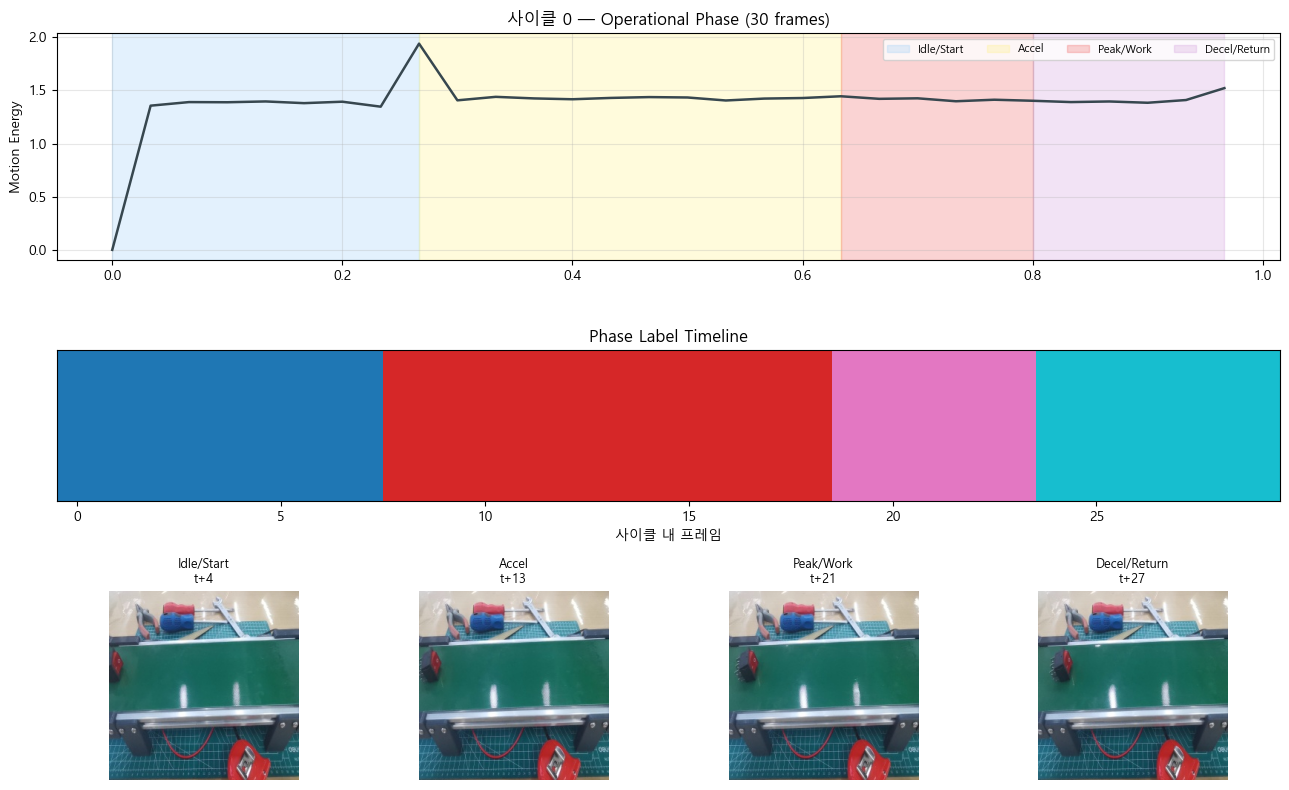

저장: output_ipad\figures\15_phase_heatmap.png


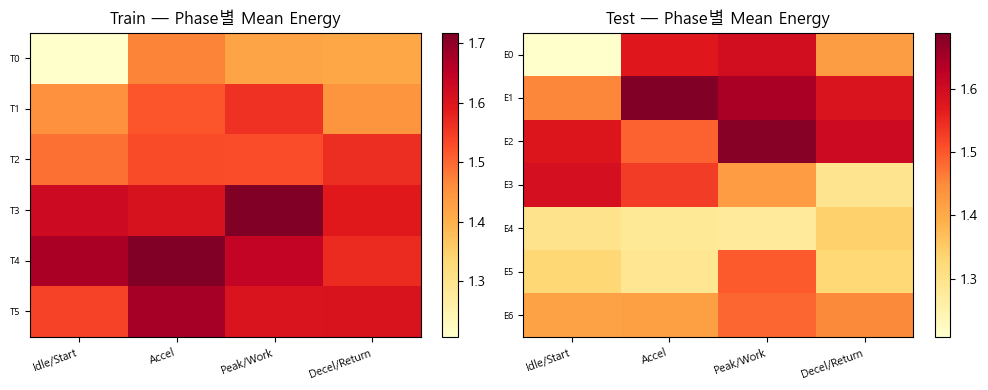

In [14]:
def segment_operational_phases(
    cycle_motion: np.ndarray,
    *,
    n_phases: int = 4,
) -> tuple[list[tuple[int, int]], np.ndarray]:
    """
    사이클 1개를 Motion Energy peak 기준 n_phases 구간으로 분할.
    반환: ([(start,end),...], phase_label_per_frame)
    """
    c = cycle_motion.astype(np.float64)
    # distance: peak 간 최소 간격 — 너무 촘촘한 작은 peak 제거
    peaks, props = sp_signal.find_peaks(c, distance=max(3, len(c) // 8), prominence=c.std() * 0.3)
    if len(peaks) == 0:
        peaks = np.array([int(np.argmax(c))])

    boundaries = [0]
    for p in peaks:
        boundaries.append(int(p))
    boundaries.append(len(c))
    boundaries = sorted(set(boundaries))

    # n_phases에 맞게 boundary 보간
    while len(boundaries) - 1 < n_phases:
        # 가장 긴 구간을 반으로 분할
        spans = [(boundaries[i + 1] - boundaries[i], i) for i in range(len(boundaries) - 1)]
        _, idx = max(spans)
        mid = (boundaries[idx] + boundaries[idx + 1]) // 2
        boundaries.insert(idx + 1, mid)
    boundaries = boundaries[: n_phases + 1]

    segments = [(boundaries[i], boundaries[i + 1]) for i in range(n_phases)]
    labels = np.zeros(len(c), dtype=int)
    for pi, (s, e) in enumerate(segments):
        labels[s:e] = pi
    return segments, labels


# 산업 설비 사이클 내 4단계 운전 상태 (리프트·컨베이어 등에 일반적)
PHASE_NAMES = ["Idle/Start", "Accel", "Peak/Work", "Decel/Return"]


def plot_phase_segmentation(
    frames: list[np.ndarray],
    cycle_motion: np.ndarray,
    period: int,
    cycle_index: int = 0,
    fps: float = 30.0,
    *,
    save_path: Path | None = None,
) -> None:
    """대표 사이클 phase 분할 + 구간별 키프레임 + phase timeline."""
    start = cycle_index * period
    seg_motion = cycle_motion[:period] if len(cycle_motion) >= period else cycle_motion
    segments, labels = segment_operational_phases(seg_motion, n_phases=4)
    phase_colors = ["#90caf9", "#fff176", "#ef5350", "#ce93d8"]

    fig = plt.figure(figsize=(13, 8))
    gs = GridSpec(3, 4, figure=fig, height_ratios=[1.2, 0.8, 1.0])

    ax_wave = fig.add_subplot(gs[0, :])
    t = np.arange(len(seg_motion)) / fps
    ax_wave.plot(t, seg_motion, color="#37474f", lw=1.8)
    for pi, (s, e) in enumerate(segments):
        ax_wave.axvspan(t[s], t[min(e, len(t) - 1)], alpha=0.25, color=phase_colors[pi],
                        label=PHASE_NAMES[pi])
        mid = (s + e) // 2
        if start + mid < len(frames):
            pass
    ax_wave.set_ylabel("Motion Energy")
    ax_wave.set_title(f"사이클 {cycle_index} — Operational Phase ({period} frames)")
    ax_wave.legend(loc="upper right", ncol=4, fontsize=8)
    ax_wave.grid(alpha=0.3)

    ax_bar = fig.add_subplot(gs[1, :])
    ax_bar.imshow(labels[np.newaxis, :], aspect="auto", cmap="tab10", vmin=0, vmax=3)
    ax_bar.set_yticks([])
    ax_bar.set_xlabel("사이클 내 프레임")
    ax_bar.set_title("Phase Label Timeline")

    for pi, (s, e) in enumerate(segments):
        ax_kf = fig.add_subplot(gs[2, pi])
        mid = min(start + (s + e) // 2, len(frames) - 1)
        ax_kf.imshow(cv2.cvtColor(frames[mid], cv2.COLOR_BGR2RGB))
        ax_kf.set_title(f"{PHASE_NAMES[pi]}\nt+{mid - start}", fontsize=9)
        ax_kf.axis("off")

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"저장: {save_path}")
    plt.show()


def compare_phase_energy_profiles(
    train_cycles: list[np.ndarray],
    test_cycles: list[np.ndarray] | None,
    *,
    save_path: Path | None = None,
) -> None:
    """phase별 평균 에너지를 train vs test heatmap으로 비교."""
    def phase_profile(cycle: np.ndarray) -> np.ndarray:
        _, labels = segment_operational_phases(cycle, n_phases=4)
        return np.array([cycle[labels == p].mean() if np.any(labels == p) else 0.0 for p in range(4)])

    train_prof = np.stack([phase_profile(c) for c in train_cycles[:12]], axis=0)
    fig, axes = plt.subplots(1, 2 if test_cycles else 1, figsize=(10 if test_cycles else 5, 4))
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])
    im0 = axes[0].imshow(train_prof, aspect="auto", cmap="YlOrRd")
    axes[0].set_yticks(range(len(train_prof)))
    axes[0].set_yticklabels([f"T{i}" for i in range(len(train_prof))], fontsize=7)
    axes[0].set_xticks(range(4))
    axes[0].set_xticklabels(PHASE_NAMES, rotation=20, ha="right", fontsize=8)
    axes[0].set_title("Train — Phase별 Mean Energy")
    fig.colorbar(im0, ax=axes[0], fraction=0.04)
    if test_cycles:
        test_prof = np.stack([phase_profile(c) for c in test_cycles[:12]], axis=0)
        im1 = axes[1].imshow(test_prof, aspect="auto", cmap="YlOrRd")
        axes[1].set_yticks(range(len(test_prof)))
        axes[1].set_yticklabels([f"E{i}" for i in range(len(test_prof))], fontsize=7)
        axes[1].set_xticks(range(4))
        axes[1].set_xticklabels(PHASE_NAMES, rotation=20, ha="right", fontsize=8)
        axes[1].set_title("Test — Phase별 Mean Energy")
        fig.colorbar(im1, ax=axes[1], fraction=0.04)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"저장: {save_path}")
    plt.show()


plot_phase_segmentation(
    train_frames, train_motion[0:period_frames], period_frames, cycle_index=0,
    fps=fps_assumed, save_path=FIG_DIR / "14_phase_segmentation.png",
)
compare_phase_energy_profiles(
    cycles, test_cycles if test_clip else None,
    save_path=FIG_DIR / "15_phase_heatmap.png",
)


# IPAD 산업 Temporal Pattern — 전체 Vision 기술 요약

## 데이터: IPAD
- 실습: **`IPAD_sample.zip`** (약 11MB) → 자동 압축 해제 `IPAD_Sample/` (R01, 클립 01)
- 전체: 16종 산업 설비, synthetic + real, **주기성(periodicity) 주석**
- 구조: `{설비}/training/frames/{클립}/*.jpg` (정상), `testing/` (이상 포함)
- 1사이클 **5~30초**, 설비 내 주기 **거의 고정** (이상 시 변화)

## 본 실습 파이프라인

| 단계 | 기법 | 산업적 의미 |
|------|------|-------------|
| Motion Energy | 프레임 차분 | 설비 **동작 vs 정지** 구간 |
| Autocorr / FFT | 주기 T 추정 | **1사이클 길이** (IPAD periodicity) |
| Cycle Segmentation | T 단위 분할 | Period Memory / Sliding Window 기초 |
| Optical Flow | Farneback HSV | 부품 **이동 방향·속도** |
| Train vs Test | Z-score | **정상 패턴 대비 이상** 사이클 |
| STFT | 시간-주파수 | **국소 주기 drift·과도** 구간 |
| DTW | 비선형 정렬 | 사이클 **형태(shape)** 이상 |
| CUSUM / Rolling Period | 순차 통계 | **change-point·주기 변화** 시점 |
| Mahalanobis | 다변량 거리 | feature **상관** 반영 이상 점수 |
| Phase Segmentation | peak 기반 | 사이클 내 **운전 단계** 구조 |

## 01 Temporal Vision과의 관계
- **01**: Optical Flow → 3D CNN → TimeSformer (일반 Video AI)
- **02**: 동일 Motion/Flow 기법을 **산업 주기 분석**에 특화
- IPAD 논문 VAD: reconstruction + **period classification** (심화)

## 참고
- [IPAD GitHub](https://github.com/LJF1113/IPAD) · [Project Page](https://ljf1113.github.io/IPAD_VAD/)
- Liu et al., *IPAD: Industrial Process Anomaly Detection Dataset*, arXiv:2404.15033


In [15]:
# 분석 결과 요약 출력
print("결과 저장:", FIG_DIR.resolve())
print("분석 설비:", train_clip.device)
print(f"추정 주기: {period_frames} frames ≈ {period_frames/fps_assumed:.2f}s")
print("고급 분석 figure: 08_stft ~ 15_phase_heatmap (STFT·DTW·CUSUM·Mahalanobis·Phase)")


결과 저장: C:\MyCursorLab\08_Video AI 처리 및 분석\output_ipad\figures
분석 설비: R01
추정 주기: 30 frames ≈ 1.00s
고급 분석 figure: 08_stft ~ 15_phase_heatmap (STFT·DTW·CUSUM·Mahalanobis·Phase)
